## Cell 1 — Imports & Path Setup

Puts `bank_pipeline/` (`BANK_ROOT`) on `sys.path` and removes the notebook's own folder, so `feature_research` and `shared` import as packages and sibling modules (`config`, `metrics`, `validation`) can't be imported by bare name.

| Symbol | Source | Purpose |
|---|---|---|
| `setup_directories` | `feature_research.config` | Creates `research_logs/` and `research_logs/figures/` |
| `apply_global_settings` | `feature_research.config` | Seeds NumPy, sets plot style, quiets Optuna |
| `sanity_check_data` | `feature_research.validation` | Structural checks on the preprocessed data |
| `RANDOM_SEED` | `feature_research.config` | Shared seed (42); passed explicitly to every stochastic step |

In [1]:
# =============================================================================
# CELL 1: PATH BOOTSTRAP, IMPORTS & SETUP
# =============================================================================
# Standard library
import sys
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

_here = Path.cwd().resolve()

BANK_ROOT = next(
    (p for p in (_here, *_here.parents)
     if (p / "feature_research" / "__init__.py").is_file() and (p / "shared").is_dir()),
    None,
)
if BANK_ROOT is None:
    raise RuntimeError(f"Could not locate bank_pipeline/ above {_here}")

def _is_here(p):
    try:
        return Path(p or ".").resolve() == _here
    except OSError:
        return False

sys.path[:] = [p for p in sys.path if not _is_here(p)]
if str(BANK_ROOT) not in sys.path:
    sys.path.insert(0, str(BANK_ROOT))

# --- Feature-research modules (Cells 2-4 logic lives here) ---------------------
from feature_research import (
    setup_directories,
    apply_global_settings,
    sanity_check_data,
    RANDOM_SEED,
)

print("✅ All imports loaded")
print(f"   bank_pipeline root: {BANK_ROOT}")
print(f"   Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All imports loaded
   bank_pipeline root: C:\Users\phill\projects\ai-business-coach-clean\prototype\bank_pipeline
   Timestamp: 2026-10-08 10:19:30


## Cell 2 — Load & Preprocess

Reads the raw UCI Bank Marketing data and applies `BankPreprocessor`:

- Drops post-contact leaky features: `duration`, `pdays`, `poutcome`
- Encodes categoricals with fixed SQL mappings (unknown → −1); the only learned state is the `job` vocabulary (sorted, label-free)
- Target `y`: 1 = subscribed, 0 = not

**Output:** `df_processed` — (41188, 18), all numeric, no nulls.

> Path resolved by `load_and_preprocess()` via `config.DATA_PATH`; pass `path=` to override.

In [2]:
# ============================================================
# CELL 2: BUILD DATABASE & PREPROCESS
# ============================================================
from data.preprocessing import BankPreprocessor, build_database

build_database()

preprocessor = BankPreprocessor(drop_leaky=True)
df_processed = preprocessor.fit_transform()


🔧  PREPROCESSING: Bank Marketing Dataset
✅  y  →  {0: 36548, 1: 4640}
✅  binary [default, housing, loan]  (unknown=-1)
✅  contact
✅  month  →  [np.int8(3), np.int8(4), np.int8(5), np.int8(6), np.int8(7), np.int8(8), np.int8(9), np.int8(10), np.int8(11), np.int8(12)]
✅  day_of_week
✅  poutcome
✅  education  (ordinal 0-6, unknown=-1)
✅  job  →  12 categories  (unseen → -1)
✅  marital
✅  economic features  →  float64
✅  campaign features  →  unchanged numeric
⚠️   dropped leaky features: ['duration', 'pdays', 'poutcome']

✅  df_processed ready — shape: (41188, 18)
    memory: 2.91 MB



## Cell 3 — Directories & Global Settings

Creates the package-anchored output folders and applies the global seed, plot style, and Optuna log level. Run before any cell that saves files or plots.

In [3]:
# ============================================================
# CELL 3: SETUP PATHS & GLOBAL SETTINGS
# ============================================================
setup_directories()
apply_global_settings()

📁 Output directory : C:\Users\phill\projects\ai-business-coach-clean\prototype\bank_pipeline\feature_research\research_logs
📁 Figures directory: C:\Users\phill\projects\ai-business-coach-clean\prototype\bank_pipeline\feature_research\research_logs\figures
🎲 Random seed      : 42
🎨 Plot style       : seaborn-v0_8-darkgrid
🔇 Optuna logging / experimental warnings suppressed


## Cell 4 — Sanity Checks

Fails immediately if `df_processed` breaks the structural contract:

1. Target column found and strictly binary {0, 1}
2. No leaky features remain (`duration`, `pdays`, `poutcome`)
3. All columns numeric; no missing values

**Output:** `TARGET_COL` (`'y'`). Class balance 36,548 : 4,640 (7.88 : 1); handled downstream by class weights and threshold tuning.

In [4]:
# ============================================================
# CELL 4: SANITY CHECKS
# ============================================================
TARGET_COL = sanity_check_data(df_processed)


SANITY CHECKS
  Target column     : 'y'
   Class distribution : {0: 36548, 1: 4640}
   Imbalance ratio    : 7.88:1
  No leaky features : ['duration', 'pdays', 'poutcome']
  All columns numeric: 18 total
  No missing values

  Dataset shape     : (41188, 18)
   Feature columns  : 17
   Samples          : 41,188


## Cell 5 — Global Train / Test Split
`data/global_splits/split_manager.py` · `GlobalSplitManager(test_size=0.20, random_state=42)`

The only train/test split in the notebook: a stratified 80 / 20 split identical to the cascades' (same data, same seed → same rows).

| Object | Contents |
|---|---|
| `X_train`, `y_train`, `df_train` | 32,950 training rows — everything below uses only these |
| `CV` | 5-fold stratified CV inside the training rows, shared by every trainer |
| `TRAIN_INDEX_HASH` | Fingerprint of the training index, recorded in saved artifacts |

Test rows are deliberately not bound in this notebook. They stay untouched until final evaluation.

In [5]:
# ============================================================
# CELL 5: GLOBAL TRAIN / TEST SPLIT
# ============================================================
import hashlib
from sklearn.model_selection import StratifiedKFold
from data.global_splits import GlobalSplitManager

GLOBAL_SPLIT = GlobalSplitManager(test_size=0.20, random_state=RANDOM_SEED).create_split(
    df_processed, target_col=TARGET_COL
)
X_train, y_train = GLOBAL_SPLIT["X_train"], GLOBAL_SPLIT["y_train"]
df_train = X_train.assign(**{TARGET_COL: y_train})

# Folds inside the training rows — shared by every trainer
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Split fingerprint for the artifact contracts
TRAIN_INDEX_HASH = hashlib.sha256(
    pd.util.hash_pandas_object(X_train.index, index=False).values.tobytes()
).hexdigest()[:16]
print(f"Train: {X_train.shape}  |  index hash: {TRAIN_INDEX_HASH}")


📐  CREATING GLOBAL TRAIN / TEST SPLIT
    total samples : 41188
    positive rate : 0.1127
    features      : 17

✅  train : (32950, 17)  |  positive rate: 0.1127
    test  : (8238, 17)  |  positive rate: 0.1126
🔒  no train/test leakage

📦  GLOBAL_SPLIT ready
Train: (32950, 17)  |  index hash: f7caf65f64b50b45


## Cell 6 — Feature Types

Returns the **declared** feature types from `validation.py`; nothing is inferred from the data.

| List | Features |
|---|---|
| `NUMERIC_FEATURES` (8) | age, campaign, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed |
| `CATEGORICAL_FEATURES` (9) | job, marital, education, default, housing, loan, contact, month, day_of_week |

Fails if the data has missing, extra, or duplicated feature columns. The type picks the metric suite in Cell 7.

In [6]:
# ============================================================
# CELL 6: FEATURE TYPING
# ============================================================
from feature_research import classify_features

NUMERIC_FEATURES, CATEGORICAL_FEATURES = classify_features(df_processed, TARGET_COL)


FEATURE TYPING
  age                  -> numeric      (n_unique=78)
  job                  -> numeric      (n_unique=12)
  marital              -> categorical  (n_unique=4)
  education            -> categorical  (n_unique=8)
  default              -> categorical  (n_unique=3)
  housing              -> categorical  (n_unique=3)
  loan                 -> categorical  (n_unique=3)
  contact              -> categorical  (n_unique=2)
  month                -> categorical  (n_unique=10)
  day_of_week          -> categorical  (n_unique=5)
  campaign             -> numeric      (n_unique=42)
  previous             -> categorical  (n_unique=8)
  emp.var.rate         -> numeric      (n_unique=10)
  cons.price.idx       -> numeric      (n_unique=26)
  cons.conf.idx        -> numeric      (n_unique=26)
  euribor3m            -> numeric      (n_unique=316)
  nr.employed          -> numeric      (n_unique=11)

  Numeric features     : 8
  Categorical features : 9


## Cell 7 — Separation Metrics
Training rows only (`df_train`) · `feature_research/separation.py`

| Numeric | Categorical |
|---|---|
| Cohen's d — standardized mean difference | Cramér's V — χ² association |
| KS — max ECDF gap between classes | Target-rate range — max − min P(subscribe) over categories with ≥ 30 rows |
| Point-biserial r — correlation with target | |
| MI — on ≤ 10 tie-robust quantile bins | MI — on raw categories |
| Probe AUC — single-feature logistic regression | Probe AUC — each row scored by its category's subscribe rate |

**Composite** = unweighted mean of the sub-scores, each scaled to [0, 1] (MI ÷ log 2 for both types). Probe AUCs are in-sample, used for ranking only.

**Output:** `df_separation` — one row per feature, sorted by composite.

In [7]:
# ============================================================
# CELL 7: SEPARATION METRICS COMPUTATION
# ============================================================
from feature_research import compute_all_separations

df_separation = compute_all_separations(
    df_train,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    TARGET_COL,
)


📊 COMPUTING SEPARATION METRICS

📈 Numeric features (8):
  [ 8/8] nr.employed......
✅ Numeric features complete

📊 Categorical features (9):
  [ 9/9] previous......
✅ Categorical features complete

✅ Separation metrics computed for 17 features


## Cell 8 — Feature Rankings

One table of the top `top_n` features: rank, type, composite, probe AUC, MI, and effect size (Cohen's d or Cramér's V).

**Saved:** `research_logs/feature_rankings.csv`, all features and metrics, regardless of `top_n`.

In [8]:
# ============================================================
# CELL 8: RANKING TABLES
# ============================================================
from feature_research import display_feature_rankings

display_feature_rankings(df_separation, top_n=20)


FEATURE RANKINGS — top 17 of 17  (8 numeric, 9 categorical)
   #  Feature            Type   Score    AUC      MI  Effect      
  --  ------------------ ----- ------ ------ -------  ------------
   1  nr.employed        num    0.388  0.745  0.0596  d = -1.18   
   2  euribor3m          num    0.358  0.740  0.0540  d = -1.01   
   3  emp.var.rate       num    0.337  0.713  0.0384  d = -0.97   
   4  month              cat    0.267  0.659  0.0263  V = 0.27    
   5  previous           cat    0.244  0.611  0.0194  V = 0.24    
   6  cons.price.idx     num    0.162  0.607  0.0203  d = -0.42   
   7  contact            cat    0.118  0.609  0.0114  V = 0.14    
   8  cons.conf.idx      num    0.096  0.538  0.0449  d = +0.18   
   9  default            cat    0.078  0.564  0.0057  V = 0.10    
  10  campaign           num    0.071  0.553  0.0025  d = -0.21   
  11  education          cat    0.068  0.562  0.0026  V = 0.07    
  12  marital            cat    0.053  0.541  0.0016  V = 0.06    
 

## Cell 9 — Separation Plots
Training rows only · `feature_research/visualization.py`

One figure per top-ranked feature, saved to `research_logs/figures/<rank>_<feature>.png` (rank prefix keeps files in ranking order).

| Numeric (3 panels) | Categorical (2 panels) |
|---|---|
| Violin by class | P(subscribe) per category ± 95 % Wilson CI, overall rate dashed |
| Density overlay | Class counts per category (grouped bars) |
| ECDF — largest vertical gap = KS | |

`top_n=17` plots every feature. Add `show=True` to display the plots inline as well as saving them.

In [9]:
# ============================================================
# CELL 9: VISUALIZATIONS FOR TOP FEATURES
# ============================================================
from feature_research import generate_all_plots

generate_all_plots(df_train, df_separation, TARGET_COL, top_n=17)


SEPARATION PLOTS — top 17 features (8 numeric, 9 categorical), 32,950 rows
  Saved 17 figures → C:\Users\phill\projects\ai-business-coach-clean\prototype\bank_pipeline\feature_research\research_logs\figures
  Numeric: violin · density overlay · ECDF   |   Categorical: rate ± Wilson CI · class counts


## Cell 10 — Interaction Discovery
Training rows only · `feature_research/interactions.py`

Finds feature pairs that carry information neither feature has alone:

$$\text{lift} = \text{MI}(f_1 \times f_2;\ y) - \text{MI}(f_1;\ y) - \text{MI}(f_2;\ y)$$

1. Score every feature's MI with the target; keep the top 30 as candidates (all 17 here → 136 pairs).
2. Numeric features → ≤ 5 tie-robust quantile bins; categoricals used as-is.
3. Each pair's joint token (`bin₁ × 100 + bin₂`) is scored against the target.
4. All MIs are Miller–Madow bias-corrected, so pairs with many joint cells get no built-in bonus.

**Output:** `df_interactions` — top `top_k=25` pairs by lift. **Saved:** `research_logs/interaction_rankings.csv`.

> Macro indicators are month-level constants, so macro × macro pairs mostly reflect finer timing, not true synergy.


In [10]:
# ============================================================
# CELL 10: INTERACTION DISCOVERY
# ============================================================
from feature_research import search_interactions_mi, display_interaction_rankings


df_interactions = search_interactions_mi(
    df_train,
    NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    TARGET_COL,
    numeric_features=NUMERIC_FEATURES,
    top_k=25,
    max_pairs=500,
)

display_interaction_rankings(df_interactions, top_n=25)


INTERACTION DISCOVERY — top 25 by MI lift
  17 features, 136 pairs evaluated, 32,950 rows
   #  Pair                                 Joint MI   Sum MI     Lift  Lift %
  --  ------------------------------------ -------- -------- -------- -------
   1  cons.price.idx × cons.conf.idx         0.0506   0.0253  +0.0253   +100%
   2  month × cons.price.idx                 0.0633   0.0405  +0.0229    +56%
   3  emp.var.rate × cons.conf.idx           0.0620   0.0425  +0.0195    +46%
   4  month × cons.conf.idx                  0.0548   0.0371  +0.0177    +48%
   5  contact × cons.conf.idx                0.0395   0.0223  +0.0172    +77%
   6  nr.employed × cons.conf.idx            0.0593   0.0504  +0.0090    +18%
   7  previous × cons.conf.idx               0.0385   0.0302  +0.0082    +27%
   8  cons.price.idx × contact               0.0324   0.0257  +0.0068    +26%
   9  euribor3m × cons.conf.idx              0.0577   0.0517  +0.0060    +12%
  10  emp.var.rate × cons.price.idx          0.0510

## Cell 11 — Build Features

**Source:** `feature_research.feature_engineering.FeaturePipeline`

Fits the feature pipeline on the training rows and builds `df_engineered`
(training rows + target), used for inspection in Cells 12–15.

`FE_PARAMS` holds the pipeline settings in one place. `make_feature_pipeline()`
returns a fresh, unfitted pipeline with those settings; the trainers use it to
refit features inside every CV fold.

### Outputs

| Variable | Use |
|---|---|
| `df_engineered` | Full-train feature frame (inspection, contract checks) |
| `make_feature_pipeline` | Per-fold feature factory for the trainers |
| `FE_PARAMS` | Pipeline settings |

In [11]:
# ============================================================
# CELL 11: BUILD FEATURES — fit on training rows
# ============================================================
from functools import partial
from feature_research.feature_engineering import FeaturePipeline

FE_PARAMS = dict(random_state=RANDOM_SEED, n_bins=20, smoothing_factor=100)
make_feature_pipeline = partial(FeaturePipeline, **FE_PARAMS)

fp = make_feature_pipeline()
df_engineered = fp.fit_transform(X_train, y_train).assign(**{TARGET_COL: y_train})

## Cell 12A — Crisis Features
`feature_engineering/crisis.py` · deterministic (no target, no fitting)

| Column | Role | Feeds |
|---|---|---|
| `cellular_crisis` | **LIVE — LR** | — |
| `economic_crisis_score` | intermediate | `cellular_crisis` |
| `high_conversion_month` | intermediate | `behavioral_favorability` (10F) |
| `cellular_contact` | intermediate | `behavioral_favorability` (10F) |
| `default_clean` | intermediate | `behavioral_favorability`, `overlap_default_clean` (10F) |

- **Crisis score (0–6):** `3·[euribor3m < 1.5] + 2·[emp.var.rate < −1.0] + 1·[nr.employed < 5100]`. Crisis = score ≥ 3.
- **`cellular_crisis`** = cellular contact **and** crisis.
- **`high_conversion_month`** = Mar / Sep / Oct / Dec. **`default_clean`** = `default == "no"` (unknown counts as not clean).
- Thresholds and weights are fixed constants from the original 10A exploration.

> Pruned: 26 unused features from the original `engineer_bank_features()`.

In [12]:
# ============================================================
# CELL 12A: ECONOMIC CRISIS FEATURES
# ============================================================ 
print("\n" + "="*70)
print("✅ CELL 12A — CRISIS FEATURES")
print("="*70)
print(f"\n{'Feature':<30} {'Values / Stats':>35}")
print("-"*70)
for feat in ['economic_crisis_score', 'cellular_crisis',
             'high_conversion_month', 'cellular_contact', 'default_clean']:
    vc = df_engineered[feat].value_counts().sort_index().to_dict()
    print(f"   {feat:<28} {str(vc):>35}")
 
rate_crisis = df_engineered.loc[df_engineered['cellular_crisis'] == 1, TARGET_COL].mean()
rate_no_crisis = df_engineered.loc[df_engineered['cellular_crisis'] == 0, TARGET_COL].mean()
print(f"\n   cellular_crisis=1 subscribe rate: {rate_crisis:.4f}")
print(f"   cellular_crisis=0 subscribe rate: {rate_no_crisis:.4f}")
print(f"   Lift: {rate_crisis / rate_no_crisis:.2f}x")
print("="*70)


✅ CELL 12A — CRISIS FEATURES

Feature                                             Values / Stats
----------------------------------------------------------------------
   economic_crisis_score               {0: 22126, 3: 227, 6: 10597}
   cellular_crisis                              {0: 23215, 1: 9735}
   high_conversion_month                        {0: 31320, 1: 1630}
   cellular_contact                            {0: 12042, 1: 20908}
   default_clean                                {0: 6943, 1: 26007}

   cellular_crisis=1 subscribe rate: 0.2480
   cellular_crisis=0 subscribe rate: 0.0559
   Lift: 4.44x


## Cell 12B — Integral Features
`feature_engineering/integrals.py`

| Column | Role | Feeds |
|---|---|---|
| `neighborhood_subscription_density` | **LIVE — RF** | `decay_x_density` (10C) |
| `economic_stress_integral` | intermediate | `prior_x_stress` (10E), `low_stress_zone` (10F) |

- **`economic_stress_integral`** — deterministic. Weighted sum (3 : 2 : 1) of how far euribor3m is below 1.5, emp.var.rate below 0, and nr.employed below 5200. 0 = no stress; max ≈ 0.94 on this data.
- **`neighborhood_subscription_density`** — **target-derived.** Gaussian kernel-weighted subscribe rate of 5,000 reference rows in standardized (euribor3m, nr.employed, emp.var.rate) space, bandwidth 1.0. Scaler and reference rows are fit on training rows only (`IntegralFeatureEngineer`).

> Runtime ≈ 30–60 s. Pruned: `cumulative_campaign_pressure`, `pressure_density_synergy`.

In [13]:
# ============================================================
# CELL 12B: INTEGRAL FEATURES
# ============================================================
print("\n" + "="*70)
print("✅ CELL 12B — INTEGRAL FEATURES")
print("="*70)
 
for feat in ['economic_stress_integral', 'neighborhood_subscription_density']:
    s = df_engineered[feat]
    print(f"\n   {feat}")
    print(f"      range: [{s.min():.4f}, {s.max():.4f}]   mean: {s.mean():.4f}   std: {s.std():.4f}")
 
# Separation check: do these features differ by target class?
print(f"\n   Class separation check (mean by target):")
for feat in ['economic_stress_integral', 'neighborhood_subscription_density']:
    means = df_engineered.groupby(TARGET_COL)[feat].mean()
    print(f"   {feat:<40} sub={means[1]:.4f}  no-sub={means[0]:.4f}")
print("="*70)


✅ CELL 12B — INTEGRAL FEATURES

   economic_stress_integral
      range: [0.0000, 0.9439]   mean: 0.1858   std: 0.2764

   neighborhood_subscription_density
      range: [0.0462, 0.3544]   mean: 0.1044   std: 0.0867

   Class separation check (mean by target):
   economic_stress_integral                 sub=0.4658  no-sub=0.1502
   neighborhood_subscription_density        sub=0.1921  no-sub=0.0932


## Cell 12C — Derivative Features
`feature_engineering/derivatives.py` · requires 10B (raises otherwise)

| Column | Role |
|---|---|
| `euribor3m_sigmoid_slope`, `emp_var_rate_sigmoid_slope` | **LIVE — EBM** |
| `euribor3m_local_rate` | **LIVE — LR** |
| `economic_curvature_intensity` | **LIVE — RF + EBM** |
| `joint_economic_decay` | **LIVE — RF** (also feeds `decay_x_density`) |
| `decay_x_density` | **LIVE — EBM** |
| `*_sigmoid`, `*_decay` (×3), `*_abs_curvature` (×3) | intermediates |

**Deterministic**
- **Sigmoid slope** — σ′ centred on a fixed cliff (euribor3m 1.5, emp.var.rate −1.0), scaled to [0, 1]; peaks at the cliff.
- **Decay** — `exp(−λ · max(0, x − x₀))` per indicator. `joint_economic_decay` (their product) is high only when all three are in the crisis regime.

**Target-derived** — fit on training rows only (`DerivativeFeatureEngineer`)
- **`euribor3m_local_rate`** — subscribe rate of the row's euribor3m quantile bin (20 bins).
- **`*_abs_curvature`** — |second difference| of those bin rates for euribor3m, nr.employed, emp.var.rate. `economic_curvature_intensity` is their mean.
- **`decay_x_density`** = `joint_economic_decay × neighborhood_subscription_density`, so it inherits 10B's target dependence.

> Pruned: `nr_employed_sigmoid/slope`, all `*_gradient` / `*_abs_gradient`, signed curvature, 4 of 5 local rates, `economic_slope_intensity`, `slope_x_stress`.

In [14]:
# ============================================================
# CELL 12C: DERIVATIVE / SLOPE / DECAY FEATURES
# ============================================================
print("\n" + "="*70)
print("✅ CELL 12C — DERIVATIVE FEATURES")
print("="*70)
 
LIVE_12C = [
    'euribor3m_sigmoid_slope',
    'emp_var_rate_sigmoid_slope',
    'euribor3m_local_rate',
    'economic_curvature_intensity',
    'joint_economic_decay',
    'decay_x_density',
]
print(f"\n   {'Feature':<35} {'min':>6} {'max':>6} {'mean':>6}")
print("   " + "-"*58)
for feat in LIVE_12C:
    s = df_engineered[feat]
    print(f"   {feat:<35} {s.min():>6.3f} {s.max():>6.3f} {s.mean():>6.3f}")
 
# Verify decay_x_density required neighborhood_subscription_density
assert 'decay_x_density' in df_engineered.columns, \
    "decay_x_density missing — integrals must run before derivatives"
print(f"\n   ✅ decay_x_density present (confirms DAG order: 12B before 12C)")
print("="*70)


✅ CELL 12C — DERIVATIVE FEATURES

   Feature                                min    max   mean
   ----------------------------------------------------------
   euribor3m_sigmoid_slope              0.003  1.000  0.288
   emp_var_rate_sigmoid_slope           0.032  0.990  0.224
   euribor3m_local_rate                 0.025  0.481  0.113
   economic_curvature_intensity         0.007  0.141  0.059
   joint_economic_decay                 0.000  0.430  0.041
   decay_x_density                      0.000  0.150  0.011

   ✅ decay_x_density present (confirms DAG order: 12B before 12C)


## Cell 12D — Temporal Features
`feature_engineering/temporal.py` · target-derived

| Column | Role |
|---|---|
| `dow_month_encoded` | **LIVE — LR + RF + EBM** |

`day_of_week` alone is weak (Cell 6: rank #15, AUC 0.509). Its signal is in the interaction with `month` (Cell 9: +10.6 % MI lift).

Smoothed subscribe rate per day × month cell, λ = 100:

    encoded = (n_cell · P_cell + λ · P_global) / (n_cell + λ)

Sparse cells shrink toward P_global; unseen cells map to P_global. Fit on training rows only (`TemporalFeatureEngineer`).

> Pruned: `dow_target_encoded`, `dow_x_stress`, `good_contact_day`, `dow_x_contact`.

In [15]:
# ============================================================
# CELL 12D: TEMPORAL FEATURES
# ============================================================
print("\n" + "="*70)
print("✅ CELL 12D — TEMPORAL FEATURES")
print("="*70)
 
s = df_engineered['dow_month_encoded']
print(f"\n   dow_month_encoded")
print(f"      range: [{s.min():.4f}, {s.max():.4f}]   mean: {s.mean():.4f}   std: {s.std():.4f}")
 
# Show top and bottom day×month combos
dm_key = df_engineered['day_of_week'].astype(str) + '_' + df_engineered['month'].astype(str)
cell_means = df_engineered.groupby(dm_key)['dow_month_encoded'].first().sort_values()
print(f"\n   Lowest encoded cells (day_month):  {dict(cell_means.head(3).round(4))}")
print(f"   Highest encoded cells (day_month): {dict(cell_means.tail(3).round(4))}")
print("="*70)


✅ CELL 12D — TEMPORAL FEATURES

   dow_month_encoded
      range: [0.0563, 0.3539]   mean: 0.1036   std: 0.0541

   Lowest encoded cells (day_month):  {'1_5': np.float64(0.0563), '3_5': np.float64(0.062), '2_5': np.float64(0.066)}
   Highest encoded cells (day_month): {'4_10': np.float64(0.3131), '1_9': np.float64(0.3206), '1_3': np.float64(0.3539)}


## Cell 12E — Prior Contact Features
`feature_engineering/prior.py` · deterministic · runs after 10B, before 10F

| Column | Role | Feeds |
|---|---|---|
| `prior_x_stress` | **LIVE — EBM** | — |
| `has_prior_contact` | intermediate | `prior_x_stress`, `behavioral_favorability` (10F) |

`previous` is a strong feature (Cell 6: rank [#4], composite [0.2966]), but its signal is almost entirely in the binary "ever contacted" split. `previous ≥ 5` converts at 60–70 % on tiny counts, so bucketed versions add noise.

- **`has_prior_contact`** = `previous ≥ 1`.
- **`prior_x_stress`** = `has_prior_contact × economic_stress_integral`: an existing relationship is worth more under economic stress. It absorbed `cumulative_campaign_pressure`'s signal (EBM round 10; importance nearly doubled when that feature was removed).

> Pruned: `previous_bucket`, `prior_x_good_month`, `prior_x_cellular`, `cold_intensity`, `warm_intensity`, `prior_x_euribor_decay`.

In [16]:
# ============================================================
# CELL 12E: PRIOR CONTACT FEATURES
# ============================================================
print("\n" + "="*70)
print("✅ CELL 12E — PRIOR CONTACT FEATURES")
print("="*70)
 
prior_vc = df_engineered['has_prior_contact'].value_counts().sort_index()
print(f"\n   has_prior_contact: {prior_vc.to_dict()}")
print(f"   Prior=0 subscribe rate: "
      f"{df_engineered.loc[df_engineered['has_prior_contact']==0, TARGET_COL].mean():.4f}")
print(f"   Prior=1 subscribe rate: "
      f"{df_engineered.loc[df_engineered['has_prior_contact']==1, TARGET_COL].mean():.4f}")
 
s = df_engineered['prior_x_stress']
print(f"\n   prior_x_stress")
print(f"      range: [{s.min():.4f}, {s.max():.4f}]   mean: {s.mean():.4f}   std: {s.std():.4f}")
means = df_engineered.groupby(TARGET_COL)['prior_x_stress'].mean()
print(f"      sub={means[1]:.4f}   no-sub={means[0]:.4f}   lift: {means[1]/max(means[0], 1e-9):.2f}x")
print("="*70)


✅ CELL 12E — PRIOR CONTACT FEATURES

   has_prior_contact: {0: 28416, 1: 4534}
   Prior=0 subscribe rate: 0.0880
   Prior=1 subscribe rate: 0.2671

   prior_x_stress
      range: [0.0000, 0.9439]   mean: 0.0717   std: 0.2041
      sub=0.2305   no-sub=0.0515   lift: 4.48x


## Cell 12F — Overlap Zone Features
`feature_engineering/overlap.py` · deterministic · last step of the DAG

In the healthy-economy regime (`economic_stress_integral < 0.2`, 67.2 % of rows) the macro features stop separating the classes; behavioral and timing signals carry what's left.

| Column | Role | Feeds |
|---|---|---|
| `cpi_high_cellular` | **LIVE — RF + EBM** | — |
| `behavioral_favorability` | **LIVE — RF + EBM** | `overlap_behavioral_score` |
| `overlap_default_clean` | **LIVE — EBM** | — |
| `overlap_behavioral_score` | **LIVE — EBM** | — |
| `low_stress_zone` | intermediate | both `overlap_*` features |

- **`cpi_high_cellular`** = `cons.price.idx ≥ 93.5` **and** cellular contact. Top interaction in Cell 9 ([+50.2 %] MI lift).
- **`behavioral_favorability`** (0–1):

      (3·cellular + 3·good_month + 2·prior_contact + 1·default_clean + 1·[age ≥ 50]) / 10

- **`overlap_default_clean`**, **`overlap_behavioral_score`** = `default_clean` and `behavioral_favorability`, active only inside `low_stress_zone`. Both are *negatively* associated with subscribing (low-stress rows convert less), and the EBM uses them that way.

> Pruned (~25): `overlap_cellular`, `overlap_good_month`, `cpi_conf_*`, `macro_sentiment`, `senior_*` / `young_*`, `default_unk_*`, `moderate_zone_*`, `overlap_density`, `high_stress_density`, `overlap_decay`, and others.

In [17]:
# ============================================================
# CELL 12F: OVERLAP ZONE INTERACTION FEATURES
# ============================================================
print("\n" + "="*70)
print("✅ CELL 12F — OVERLAP ZONE FEATURES")
print("="*70)
 
n_low = df_engineered['low_stress_zone'].sum()
print(f"\n   low_stress_zone: {n_low:,} samples ({n_low/len(df_engineered):.1%})")
print(f"   (economic_stress_integral < 0.2 — healthy economy regime)")
 
print(f"\n   {'Feature':<30} {'min':>6} {'max':>6} {'mean':>6}  sep check (sub / no-sub)")
print("   " + "-"*70)
for feat in ['cpi_high_cellular', 'behavioral_favorability',
             'overlap_default_clean', 'overlap_behavioral_score']:
    s = df_engineered[feat]
    means = df_engineered.groupby(TARGET_COL)[feat].mean()
    print(f"   {feat:<30} {s.min():>6.3f} {s.max():>6.3f} {s.mean():>6.3f}  "
          f"{means[1]:.4f} / {means[0]:.4f}")
print("="*70)


✅ CELL 12F — OVERLAP ZONE FEATURES

   low_stress_zone: 22,126 samples (67.2%)
   (economic_stress_integral < 0.2 — healthy economy regime)

   Feature                           min    max   mean  sep check (sub / no-sub)
   ----------------------------------------------------------------------
   cpi_high_cellular               0.000  1.000  0.174  0.2640 / 0.1622
   behavioral_favorability         0.000  1.000  0.331  0.4896 / 0.3111
   overlap_default_clean           0.000  1.000  0.495  0.2268 / 0.5294
   overlap_behavioral_score        0.000  0.700  0.168  0.0856 / 0.1790


## Cell 12G — Stage Feature Sets
`LIVE_FEATURES` in `feature_engineering/__init__.py` · `finalize_features`, `get_stage_df` in `feature_engineering/pipeline.py`

| Stage | Features | Frame |
|---|---|---|
| LR — Stage 1 | 3 | `df_lr` (41188, 4) |
| RF — Stage 2 | 8 | `df_rf` (41188, 9) |
| EBM — Stage 3 | 14 | `df_ebm` (41188, 15) |

1. Check every live feature exists (stops if any is missing).
2. **`finalize_features`** keeps the union of stage features + target (18 + 1) and drops 13 unused UCI columns and 15 intermediates: `df_engineered` (41188, 47) → (41188, 19).
3. **`get_stage_df`** slices one stage's features + target, in registry order. These frames feed the training cells.

`LR_FEATURES`, `RF_FEATURES`, `EBM_FEATURES` are set as aliases for the training cells.

> History: the EBM set went from 57 features to 14 over 13 rounds of simplification; AUC 0.8015 → ~0.801 (within noise).

In [18]:
# ============================================================
# CELL 12G: STAGE-SPECIFIC FEATURE SETS
# ============================================================
from feature_research.feature_engineering import (
    LIVE_FEATURES,
    finalize_features,
    get_stage_df,
)
 
_STAGE_LABELS = {'lr': 'Stage 1', 'rf': 'Stage 2', 'ebm': 'Stage 3'}
 
# ── Verify all live features are present before finalizing ──────────
print("\n" + "="*70)
print("🎯 CELL 12G — STAGE-SPECIFIC FEATURE SETS")
print("="*70)
 
all_missing = set()
for stage, features in LIVE_FEATURES.items():
    print(f"\n   {stage.upper()} ({_STAGE_LABELS[stage]}): {len(features):2d} features")
    for f in features:
        present = "✅" if f in df_engineered.columns else "⚠️  MISSING"
        if "MISSING" in present:
            all_missing.add(f)
        print(f"      {present} {f}")
 
print(f"\n{'='*70}")
if all_missing:
    print(f"⚠️  Missing: {sorted(all_missing)}")
    raise RuntimeError("Fix missing features before finalizing.")
 
# ── Finalize: positive-select to model-consumed cols only ───────────
cols_before  = list(df_engineered.columns)
shape_before = df_engineered.shape

df_engineered = finalize_features(df_engineered, LIVE_FEATURES, target_col=TARGET_COL)

kept         = set(df_engineered.columns)
raw_cols     = set(df_processed.columns)
dropped_uci  = [c for c in cols_before if c in raw_cols and c not in kept]
dropped_int  = [c for c in cols_before if c not in raw_cols and c not in kept]

print("✅ All live features present — finalizing...")
print(f"\n   df_engineered: {shape_before} → {df_engineered.shape}")
print(f"   ({df_engineered.shape[1] - 1} model features + target;  "
      f"{len(dropped_uci)} UCI cols dropped, "
      f"{len(dropped_int)} intermediates dropped)")
 
# ── Stage-specific dataframes ────────────────────────────────────────
df_lr  = get_stage_df(df_engineered, 'lr',  LIVE_FEATURES, target_col=TARGET_COL)
df_rf  = get_stage_df(df_engineered, 'rf',  LIVE_FEATURES, target_col=TARGET_COL)
df_ebm = get_stage_df(df_engineered, 'ebm', LIVE_FEATURES, target_col=TARGET_COL)
 
print(f"\n   Stage dataframes (features + target):")
print(f"   df_lr  — {df_lr.shape[1]-1:2d} features + y  →  {df_lr.shape}")
print(f"   df_rf  — {df_rf.shape[1]-1:2d} features + y  →  {df_rf.shape}")
print(f"   df_ebm — {df_ebm.shape[1]-1:2d} features + y  →  {df_ebm.shape}")
 
# Convenience aliases
LR_FEATURES  = LIVE_FEATURES['lr']
RF_FEATURES  = LIVE_FEATURES['rf']
EBM_FEATURES = LIVE_FEATURES['ebm']
 
print(f"\n{'='*70}")
print(f"✅ df_lr / df_rf / df_ebm ready")
print("="*70)


🎯 CELL 12G — STAGE-SPECIFIC FEATURE SETS

   LR (Stage 1):  3 features
      ✅ cellular_crisis
      ✅ euribor3m_local_rate
      ✅ dow_month_encoded

   RF (Stage 2):  8 features
      ✅ campaign
      ✅ neighborhood_subscription_density
      ✅ cons.conf.idx
      ✅ economic_curvature_intensity
      ✅ joint_economic_decay
      ✅ dow_month_encoded
      ✅ behavioral_favorability
      ✅ cpi_high_cellular

   EBM (Stage 3): 14 features
      ✅ decay_x_density
      ✅ euribor3m_sigmoid_slope
      ✅ economic_curvature_intensity
      ✅ cons.conf.idx
      ✅ age
      ✅ dow_month_encoded
      ✅ default
      ✅ prior_x_stress
      ✅ campaign
      ✅ overlap_default_clean
      ✅ overlap_behavioral_score
      ✅ cpi_high_cellular
      ✅ behavioral_favorability
      ✅ emp_var_rate_sigmoid_slope

✅ All live features present — finalizing...

   df_engineered: (32950, 47) → (32950, 19)
   (18 model features + target;  13 UCI cols dropped, 15 intermediates dropped)

   Stage dataframes (

## Cell 13 — Pre-Training Feature Validation

**Source:** `feature_research.validation.validate_engineered_features()`

Hard validation gate before model training. Raises `AssertionError` on the first failure.

### Checks

| Check | Scope |
|---|---|
| No NaN values | Entire `df_engineered` |
| No inf values | Numeric columns |
| All stage features present | LR, RF, and EBM feature contracts |
| No NaN/inf in stage subsets | `df_lr`, `df_rf`, `df_ebm` |

Returns `True` on success.

> All validation logic lives in `validation.py` so it can be reused and tested independently.

In [19]:
# ============================================================
# CELL 13: PRE-TRAINING FEATURE VALIDATION
# ============================================================
from feature_research.validation import validate_engineered_features
 
validate_engineered_features(df_engineered, LIVE_FEATURES, target_col=TARGET_COL)


ENGINEERED FEATURE VALIDATION

   df shape: (32950, 19)
   No NaN values
   No inf values

   Stage  Features     NaN     Inf  Status
   ---------------------------------------------
   LR            3       0       0  clean
   RF            8       0       0  clean
   EBM          14       0       0  clean

All engineered features validated -- safe to train


True

## Cell 14A — Logistic Regression Training

**Source:** `feature_research.model_training.lr.train_lr`

Trains the Stage 1 logistic-regression gate on 3 continuous features using:

- `StandardScaler`
- `LogisticRegression(solver="saga", class_weight="balanced")`
- Optuna TPE, 100 trials, median pruning
- Mean ROC-AUC tuning over `C`, `penalty`, and `l1_ratio`

No recall bias is applied; threshold selection is handled downstream. This keeps LR behavior distinct from the recall-biased Stage 3 EBM.

### Leakage safety

Training uses `df_train` only. `make_feature_pipeline` is refit inside every tuning and evaluation fold, so target-derived features never see validation labels.

Reported metrics are fully out-of-fold. `lr_pipe` is the final model fit on all training rows, with an input-contract check against `df_engineered[LR_FEATURES]`.

### Outputs

| Alias | Use |
|---|---|
| `lr_result` | Result bundle used by Cell 14B |
| `lr_pipe` | Final fitted LR pipeline |
| `lr_oof` | OOF probabilities for threshold selection |
| `lr_params` | Best hyperparameters |
| `lr_metrics` | OOF AUC, recall, precision, F1, and Recall@10% FPR |
| `lr_study` | Optuna study |

**Baseline:** OOF AUC = `0.7762`.

- Δ ≥ −0.005 → **HOLD**
- Δ ≥ −0.010 → **BELOW TARGET**
- otherwise → **REGRESSED**

**Tuning note:** Recall-weighted Optuna did not improve Recall@10% FPR over balanced tuning and took about 3× longer, so the balanced objective was retained.

In [20]:
# ============================================================
# CELL 14A: LOGISTIC REGRESSION TRAINING
# ============================================================
from feature_research.model_training.lr import train_lr, LRResult

lr_result: LRResult = train_lr(
    df_train,                          # raw training rows + target
    LR_FEATURES,
    TARGET_COL,
    feature_factory=FeaturePipeline,   # class from the pipeline cell; refit per fold
    cv=CV,                             # Cell 5 splitter (tuning folds)
    random_state=RANDOM_SEED,
    baseline_auc=None,                 # 0.7875 came from the leaky protocol; re-baseline from this run
)

# Contract: lr_pipe's input is exactly df_engineered[LR_FEATURES]
pd.testing.assert_frame_equal(
    FeaturePipeline().fit_transform(X_train, y_train)[LR_FEATURES],
    df_engineered[LR_FEATURES],
)

# Aliases consumed by downstream cells
lr_pipe    = lr_result.pipe        # Pipeline(StandardScaler + LogisticRegression)
lr_params  = lr_result.params      # best Optuna hyperparameters
lr_metrics = lr_result.metrics     # out-of-fold mean/std + recall_at_10fpr
lr_study   = lr_result.study       # raw Study
lr_oof     = lr_result.oof_proba   # out-of-fold P(y=1); use for any threshold work

Tuning LR: 100 trials × 5 folds


  0%|          | 0/100 [00:00<?, ?it/s]


LOGISTIC REGRESSION (class_weight=balanced)
──────────────────────────────────────────────────────────────────────────────
Data       32,950 rows · 3 features · 3,712 positive (11.3%)
Features   refit per fold — FeaturePipeline
Tuning     100 trials (53 complete, 47 pruned) · 21.0s
           best 5-fold AUC 0.7754 (reproduced ✓) · folds 0.764 0.775 0.781 0.779 0.778
Params     C=0.000263438 · penalty=l2 · class_weight=balanced
OOF        10-fold AUC 0.7762 ± 0.0155 (moderate variance) · Recall@10%FPR 0.5073
           at 0.5: recall 0.6431 · precision 0.3148 · F1 0.4226
Coefficients (final fit, log-odds per 1 SD)


,coefficient,status
feature,,
euribor3m_local_rate,0.4236,active
cellular_crisis,0.2806,active
dow_month_encoded,0.2336,active


## Cell 14B — LR Feature Diagnostics

**Source:** `feature_research.model_training.lr.lr_diagnostics`

Descriptive checks on `LR_FEATURES` over the training rows (`df_engineered`).
Use them for feature selection; performance comes from 14A (out-of-fold).

| Section | Check | Flag |
|---|---|---|
| 1. Correlation | Pearson pairs | \|r\| > 0.70 (🔴 > 0.90) |
| 2. VIF | On standardized features | > 10 high, > 5 moderate |
| 3. Separation | Cohen's d, KS, point-biserial r (`feature_research.separation`) | \|r\| < 0.05 weak |
| 4. Coefficients | From `lr_result` (final fit, log-odds per 1 SD) | \|coef\| < 0.10 dead |
| 5. Summary | "Clean" = no high VIF, dead coefficients or weak separators | Correlated pairs are listed in 1 but don't affect it |

Plots: correlation heatmap and violin plots for the top-3 separators
(`feature_research.visualization`; `top_violin=0` skips them).

**Outputs (`lr_diag`):** `corr_matrix`, `high_pairs`, `vif_df`, `sep_df`,
`high_vif_count`, `weak_sep_features`, `dead_coef_features`.


🔬 LR FEATURE DIAGNOSTICS
   Feature set: 3 features → ['cellular_crisis', 'euribor3m_local_rate', 'dow_month_encoded']

--------------------------------------------------------------------------------
1️⃣  CORRELATION ANALYSIS
--------------------------------------------------------------------------------

✅ No high-correlation pairs (|r| > 0.7) — multicollinearity resolved!

--------------------------------------------------------------------------------
2️⃣  VARIANCE INFLATION FACTOR (VIF)
--------------------------------------------------------------------------------
   euribor3m_local_rate                     VIF=    1.98  ✅ LOW
   cellular_crisis                          VIF=    1.57  ✅ LOW
   dow_month_encoded                        VIF=    1.37  ✅ LOW

✅ All VIF < 10 — multicollinearity resolved!

--------------------------------------------------------------------------------
3️⃣  CLASS SEPARATION
------------------------------------------------------------------------------

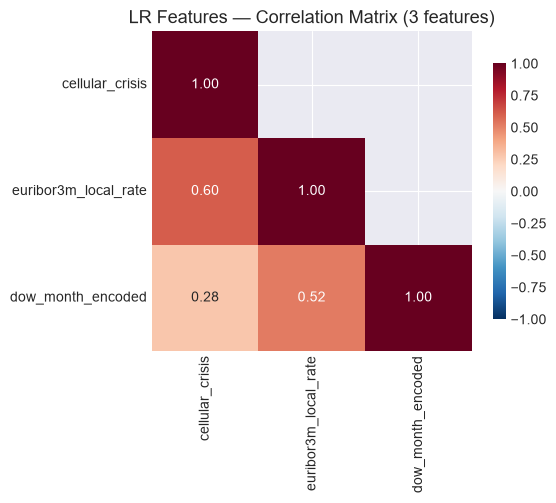


📊 Violin plots — top 3 separator(s)...


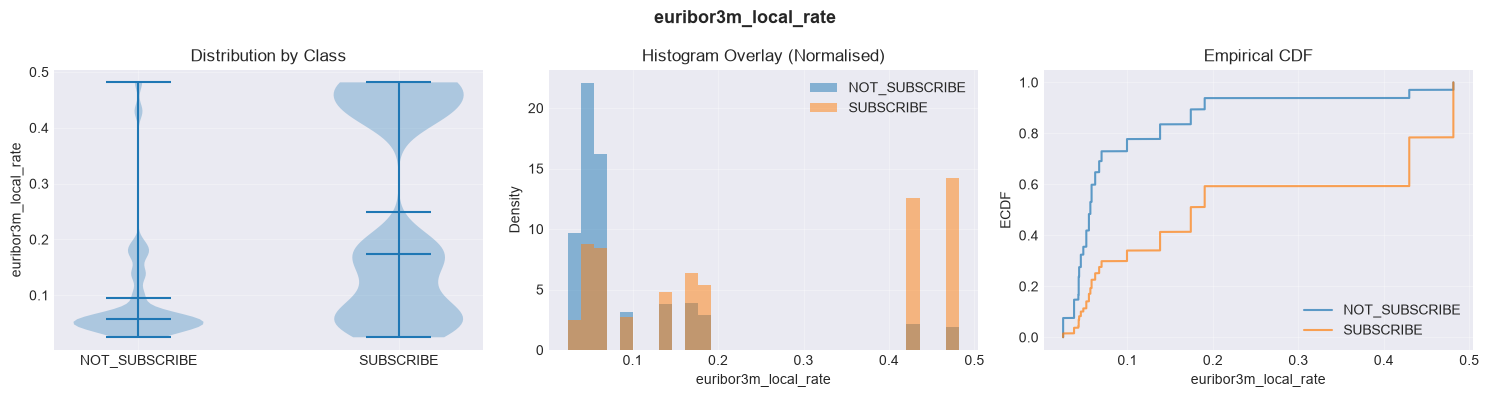

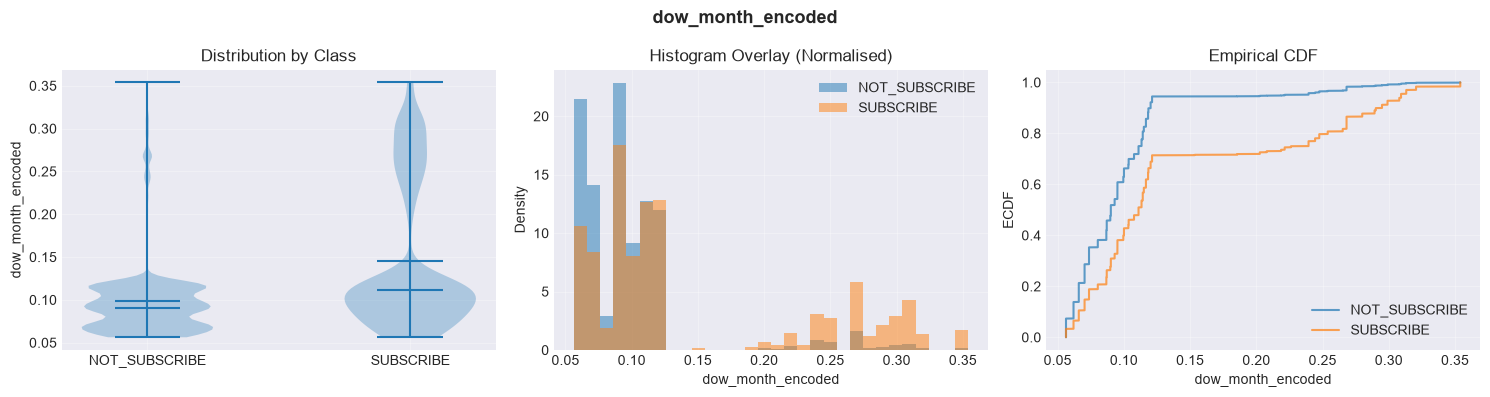

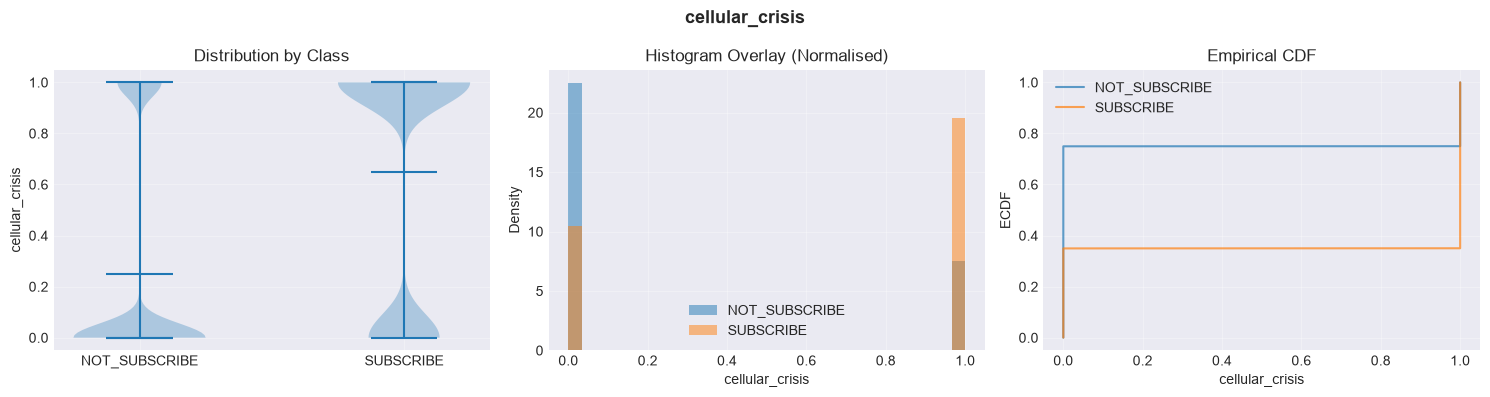


✅ LR diagnostics complete


In [21]:
# ============================================================
# CELL 14B: LR FEATURE DIAGNOSTICS
# ============================================================
from feature_research.model_training.lr import lr_diagnostics

lr_diag = lr_diagnostics(
    lr_result,
    df_engineered,
    LR_FEATURES,
    TARGET_COL,
    top_violin=3,   # violin plots for top-3 separators; set 0 to skip
)

# lr_diag dict available for downstream inspection:
#   lr_diag["vif_df"]            — full VIF table
#   lr_diag["high_pairs"]        — correlated feature pairs
#   lr_diag["sep_df"]            — separation metrics per feature
#   lr_diag["dead_coef_features"] — candidates to drop next pruning round

## Cell 15A — RF Lift Analysis: Binning Strategy

**Source:** `feature_research.model_training.rf.rf_lift_analysis`

Measures decile lift (conversion rate ÷ base rate) for the 8 continuous RF source features on training rows. This analysis was used to choose the thresholds currently locked in `binning.py` and now serves as a sanity check for whether those thresholds still align with meaningful lift breaks.

Each feature prints decile lift values (`▲ > 1.5×`, `▼ < 0.7×`) and contributes to the saved lift-curve figure.

**Inputs:**  
- `df_rf = get_stage_df(df_engineered, "rf")`
- `RF_FEATURES` — 8 continuous source features

**Outputs:**  
- `lift_results` — overall conversion rate plus per-feature bin/count/conversion/lift tables
- `FIG_DIR/rf_lift_curves.png`

> **Technical note / TODO:** Several source features are target-derived, and `df_engineered` is fit on all training rows, so this diagnostic is in-sample and can overstate lift. NSD and ECI also show drift from the originally documented lift ranges. Re-derive and freeze these thresholds under the finalized protocol in PR 39.


RF LIFT ANALYSIS — 8 continuous sources · base rate 0.113
──────────────────────────────────────────────────────────────────────────────
Decile lift, low → high value (▲ > 1.5×, ▼ < 0.7×)
  campaign                            1.10   0.96   0.77   0.50▼
  neighborhood_subscription_density   0.28▼  0.46▼  0.51▼  0.47▼  0.45▼  0.46▼  1.04   1.05   1.38   4.06▲
  cons.conf.idx                       1.22   0.54▼  0.50▼  0.40▼  4.16▲  0.63▼  0.48▼  3.73▲
  economic_curvature_intensity        0.57▼  0.47▼  0.49▼  0.49▼  0.82   0.97   0.50▼  1.69▲  1.49   3.48▲
  joint_economic_decay                0.49▼  0.49▼  0.46▼  0.48▼  0.27▼  0.40▼  1.04   1.05   1.38   4.06▲
  dow_month_encoded                   0.50▼  0.57▼  0.62▼  0.73   0.79   0.84   0.93   1.02   1.07   3.52▲
  behavioral_favorability             0.36▼  0.59▼  0.95   1.23   1.86▲  3.91▲
  cpi_high_cellular (by value)       0: 0.89 · 1: 1.52▲
Lift curves saved → C:\Users\phill\projects\ai-business-coach-clean\prototype\bank_pipelin

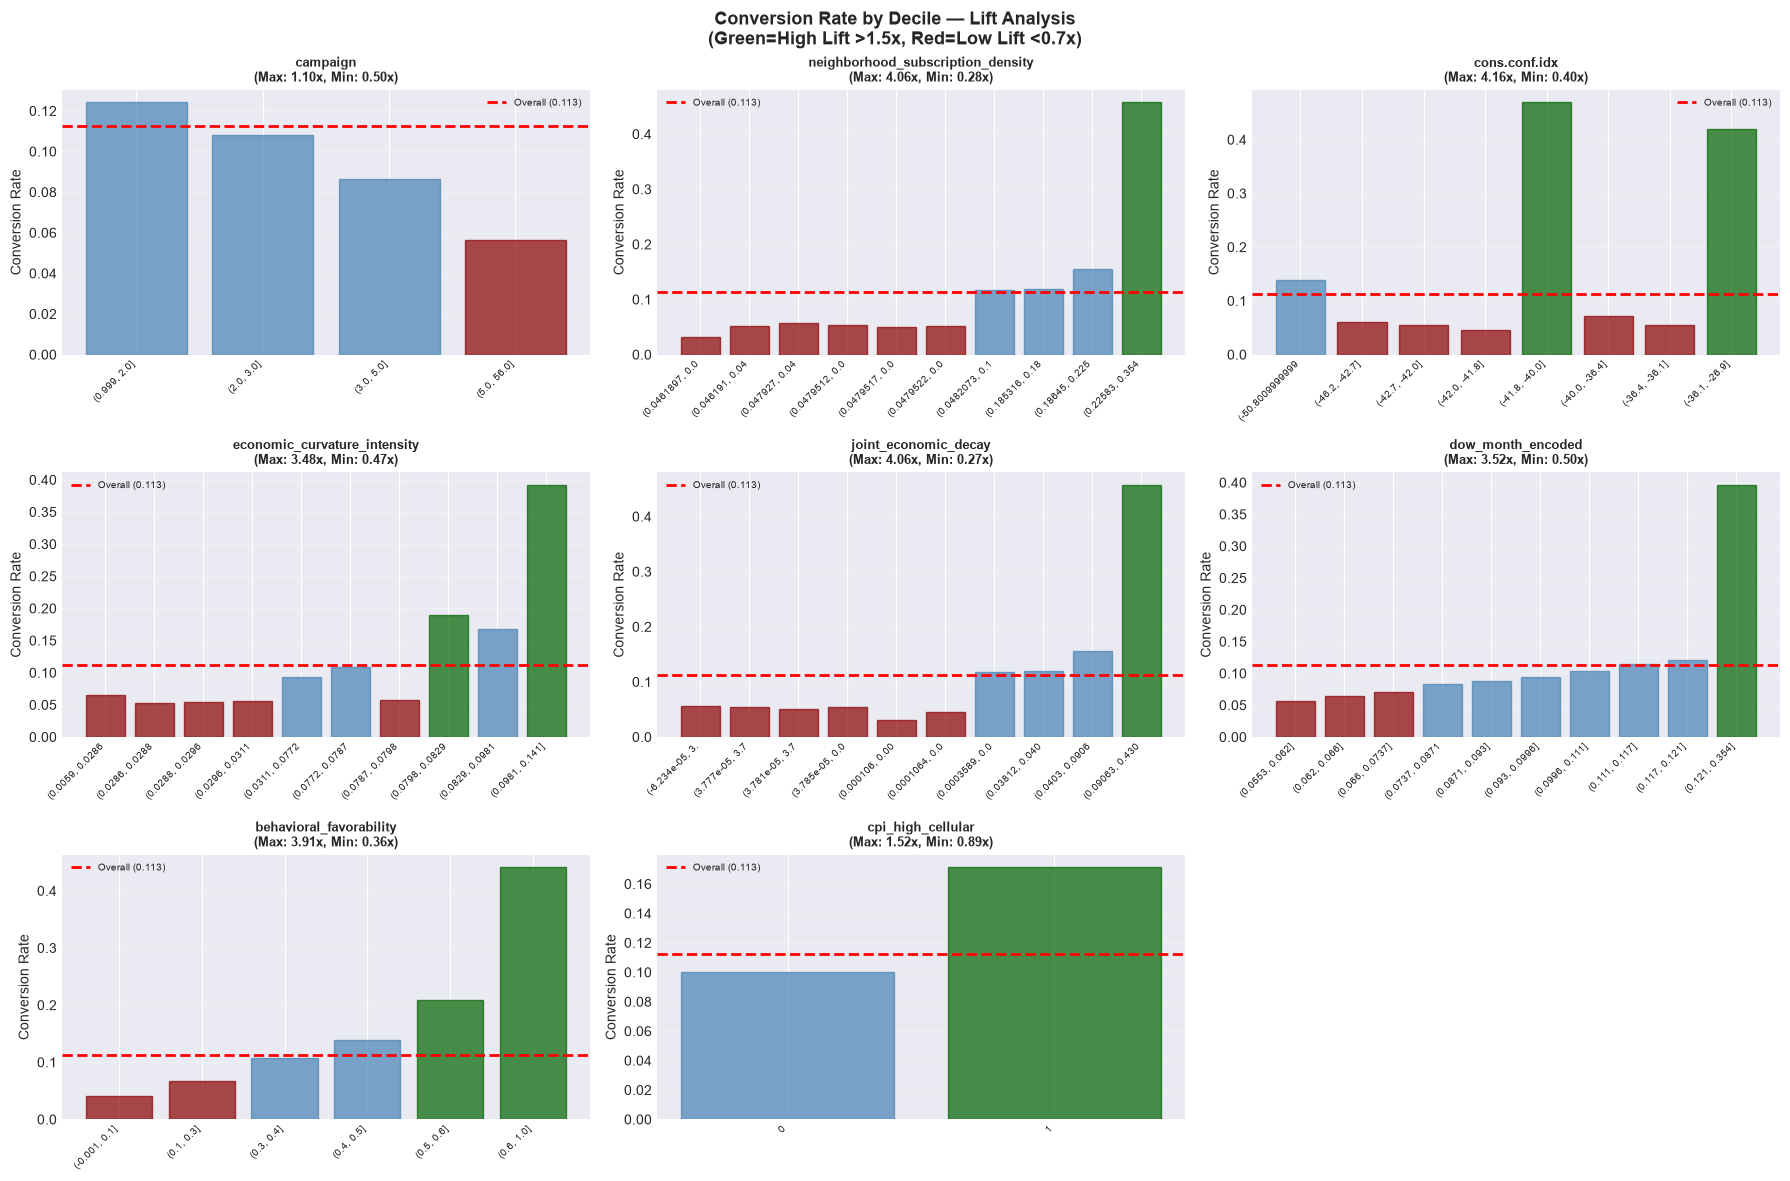

In [22]:
# ============================================================
# CELL 15A: RF LIFT ANALYSIS — BINNING STRATEGY
# ============================================================
from feature_research.model_training.rf import rf_lift_analysis

lift_results = rf_lift_analysis(df_rf, RF_FEATURES, TARGET_COL)

## Cell 15B — Feature Binning: Lift-Driven Multi-Bin Encoding

**Source:** `feature_research.model_training.rf` — `create_binary_features`, `validate_binary_features`, `BinaryFeaturePipeline`, `RF_FEATURES_BINARY`

Converts the 8 continuous RF source features into 29 binary features using fixed thresholds from `BINNING_STRATEGY`. Seven feature groups use mutually exclusive bins; `cpi_cellular` is passed through directly.

The thresholds are fixed constants, so no fitting occurs during binning. These binary features form the shared input space for the RF stage and GLASS Router.

### Validation

`validate_binary_features` is a hard contract check. It raises `ValueError` unless:

- every output column is binary (`0/1`)
- every row belongs to exactly one bin within each mutually exclusive group

`make_rf_feature_pipeline` combines the Cell 11 feature pipeline with the locked binning step. Cells 15C and 15D instantiate it inside each fold so any upstream learned features are refit using training rows only.

### Outputs

| Variable | Use |
|---|---|
| `df_rf_binary` | Full-training binary frame for inspection and contract checks |
| `RF_FEATURES_BINARY` | Ordered 29-feature contract used by 15C and 15D |
| `make_rf_feature_pipeline` | Per-fold feature + binning pipeline factory |

> **Design note:** A single above/below flag loses important feature levels. Multi-bin encoding preserves those distinctions so conjunctions such as `nsd_hot AND jed_cold` remain distinguishable from `nsd_hot AND jed_hot`. JED thresholds are intentionally offset from NSD thresholds to reduce redundant behavior.

> **Technical note:** The binning itself is deterministic and leakage-safe because its thresholds are fixed. Any leakage risk comes from upstream learned source features, which must be fitted within the training population before these fixed bins are applied.

In [23]:
# ============================================================
# CELL 15B: FEATURE BINNING — LIFT-DRIVEN MULTI-BIN ENCODING
# ============================================================
from functools import partial
from feature_research.model_training.rf import (
    BinaryFeaturePipeline,
    create_binary_features,
    validate_binary_features,
)

# Per-fold RF features: Cell 11 feature pipeline → locked binning
make_rf_feature_pipeline = partial(BinaryFeaturePipeline, make_feature_pipeline)

df_rf_binary, RF_FEATURES_BINARY = create_binary_features(df_engineered, TARGET_COL)

# Hard stop: 0/1 values, mutual exclusivity and completeness across all 7 groups
validate_binary_features(df_rf_binary, TARGET_COL, verbose=True);


RF BINNING — 8 sources → 29 binary columns · base rate 0.113
──────────────────────────────────────────────────────────────────────────────
Lift per bin (share of rows); ▲ > 1.5×, ▼ < 0.7×
  NSD       cold 0.44×▼ (67%) · warm 1.12× (21%) · elevated 3.13×▲ (4%) · hot 4.30×▲ (8%)
  JED       cold 0.44×▼ (59%) · transition 0.80× (11%) · warm 1.21× (21%) · hot 4.05×▲ (10%)
  CCI       low 1.22× (22%) · dead_mid 0.49×▼ (36%) · hot1 4.16×▲ (3%) · valley 0.57×▼ (33%) · hot2 3.73×▲ (6%)
  ECI       cold 0.52×▼ (22%) · mid 0.70×▼ (28%) · warm 1.04× (38%) · hot 2.46×▲ (12%)
  DOW       cold 0.50×▼ (13%) · low 0.65×▼ (31%) · mid 0.93× (48%) · hot 3.52×▲ (8%)
  BEHAV     cold 0.42×▼ (42%) · baseline 0.95× (36%) · warm 1.23× (8%) · hot 2.73×▲ (14%)
  CAMPAIGN  fresh 1.10× (69%) · moderate 0.87× (23%) · heavy 0.50×▼ (8%)
  CPI       cellular 1.52×▲ (17%)
Validation ✓ 29 columns are 0/1 · 7 groups mutually exclusive and complete · 397 observed patterns


## Cell 15C — Random Forest Training (Binary Feature Space)

**Source:** `feature_research.model_training.rf.train_rf`

Trains the Stage 2 random forest on the 29 binary features from Cell 15B using:

- `RandomForestClassifier(class_weight="balanced")`
- tuned minority sample weighting
- Optuna TPE, 200 trials, median pruning
- mean ROC-AUC over `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`, and `minority_weight`

### Leakage safety

Training uses `df_train` only. `make_rf_feature_pipeline` is refit inside every tuning and evaluation fold, so learned upstream features never see validation labels.

Reported metrics are fully out-of-fold. `rf_pipe` is the final fit on all training rows and is checked against the ordered `df_rf_binary[RF_FEATURES_BINARY]` contract. Single-threaded prediction keeps results deterministic.

### Outputs

| Alias | Use |
|---|---|
| `rf_result` | Result bundle used by Cell 15D |
| `rf_pipe` | Final fitted RF pipeline |
| `rf_oof` | OOF probabilities for threshold selection |
| `rf_params` | Best hyperparameters |
| `rf_metrics` | OOF AUC, recall, precision, F1, and Recall@10% FPR |
| `rf_study` | Optuna study |

**Baseline:** established from the current OOF protocol. Uses the same regression bands as LR.

In [24]:
# ============================================================
# CELL 15C: RANDOM FOREST — BAYESIAN OPTIMIZATION (BINARY)
# ============================================================
from feature_research.model_training.rf import train_rf

rf_result = train_rf(
    df_train,                                   # raw training rows + target
    RF_FEATURES_BINARY,
    TARGET_COL,
    n_trials=200,
    cv=CV,                                      # Cell 5 tuning folds
    feature_factory=make_rf_feature_pipeline,   # Cell 15B; refit per fold
    random_state=RANDOM_SEED,
    baseline_auc=0.7886,   # set from this run; fit-once (leaky) OOF AUC was 0.7875
)

# Contract: rf_pipe's input is exactly df_rf_binary[RF_FEATURES_BINARY]
pd.testing.assert_frame_equal(
    make_rf_feature_pipeline().fit_transform(X_train, y_train)[RF_FEATURES_BINARY],
    df_rf_binary[RF_FEATURES_BINARY],
)

rf_pipe    = rf_result.pipe
rf_params  = rf_result.params
rf_metrics = rf_result.metrics
rf_study   = rf_result.study
rf_oof     = rf_result.oof_proba   # out-of-fold P(y=1); use for any threshold work

Tuning RF: 200 trials × 5 folds


  0%|          | 0/200 [00:00<?, ?it/s]


RANDOM FOREST (29 binary features, 397 observed patterns)
──────────────────────────────────────────────────────────────────────────────
Data       32,950 rows · 29 features · 3,712 positive (11.3%)
Features   refit per fold — BinaryFeaturePipeline(FeaturePipeline)
Tuning     200 trials (102 complete, 98 pruned) · 3080.4s
           best 5-fold AUC 0.7876 (reproduced ✓) · folds 0.780 0.797 0.789 0.783 0.788
Params     trees=1200 · depth=7 · leaf=19 · max_features=0.34 · minority_weight=10.64 · class_weight=balanced
OOF        10-fold AUC 0.7886 ± 0.0168 (moderate variance) · Recall@10%FPR 0.5711
           at 0.5: recall 0.5911 · precision 0.3893 · F1 0.4692
Baseline   0.7886 · Δ +0.0000 → ✅ HOLD
Top Gini   nsd_cold 0.264 · jed_hot 0.167 · nsd_hot 0.097 · dow_hot 0.085 · jed_cold 0.079   (full ranking: rf_diagnostics)


## Cell 15D — RF Feature Diagnostics

**Source:** `feature_research.model_training.rf.rf_diagnostics`

Ranks the 29 binary features from Cell 15C to identify strong and weak feature groups using:

1. Gini importance
2. Out-of-fold permutation importance
3. Gini/permutation agreement
4. Composite ranking
5. Tier-based cut candidates

Permutation importance is computed with fold-specific feature refits, preserving the same leakage-safe evaluation protocol used during training.

### Outputs

| Variable | Use |
|---|---|
| `rf_diag` | Feature importances, ranks, tiers, and cut candidates |

### Downstream hand-off

At the end of the cell:

- the 29 binary features are added to `df_engineered`
- `RF_FEATURES` is redirected to `RF_FEATURES_BINARY`

These features are then available to downstream EBM and cascade-analysis cells.

> **Execution note:** After Cell 15D, `RF_FEATURES` refers to the binary feature list. Rerun the earlier RF setup cells before rerunning Cell 15A.


RF FEATURE DIAGNOSTICS — 29 binary features
──────────────────────────────────────────────────────────────────────────────
Gini from the final fit · permutation importance out-of-fold (5 folds × 10 repeats, 221s)
Score = 0.40 × norm Gini + 0.60 × norm permutation (AUC drop)


,feature,gini,gini #,perm,perm ±,perm #,score,tier
rank,,,,,,,,
1,nsd_cold,0.2639,1,0.02943,0.00331,1,1.000,🟢 TIER 1 (keep)
2,jed_hot,0.1672,2,0.00530,0.00151,3,0.374,🟢 TIER 1 (keep)
3,dow_hot,0.0851,4,0.01023,0.00075,2,0.347,🟢 TIER 1 (keep)
4,nsd_hot,0.0968,3,0.00265,0.00061,5,0.214,🟢 TIER 1 (keep)
5,jed_cold,0.0794,5,0.00126,0.00044,10,0.160,🟢 TIER 1 (keep)
6,behav_cold,0.0262,10,0.00333,0.00064,4,0.120,🟢 TIER 1 (keep)
7,nsd_warm,0.0391,6,0.00133,0.00053,9,0.100,🟢 TIER 1 (keep)
8,cci_hot1,0.0208,12,0.00192,0.00067,8,0.084,🟢 TIER 1 (keep)
9,behav_hot,0.0365,7,0.00064,0.00036,18,0.082,🟢 TIER 1 (keep)


Agreement  Spearman ρ 0.764 (p=1.45e-06, moderate — some Gini bias possible) · top-10 overlap 7/10
           Gini-only top-10: behav_hot, cci_low, nsd_elevated · perm-only top-10: cci_hot1, cpi_cellular, eci_warm
Weak       Gini < 0.01: 12 · perm ≤ 0: 6 · perm < 0.001: 11 · top 13 hold 90% of Gini
Cut        Batch 1 (TIER 4): none
           Batch 2 (TIER 3): eci_mid, eci_hot, behav_warm, jed_transition, campaign_fresh, dow_low, campaign_moderate, behav_baseline, dow_mid
           Low on both: campaign_moderate, campaign_fresh, behav_baseline, dow_mid, dow_low, behav_warm, jed_transition, eci_mid, eci_cold, campaign_heavy, … (+1)
Next       keep ~20 (TIER 1–2); remove one batch at a time → re-run 15C → 15D


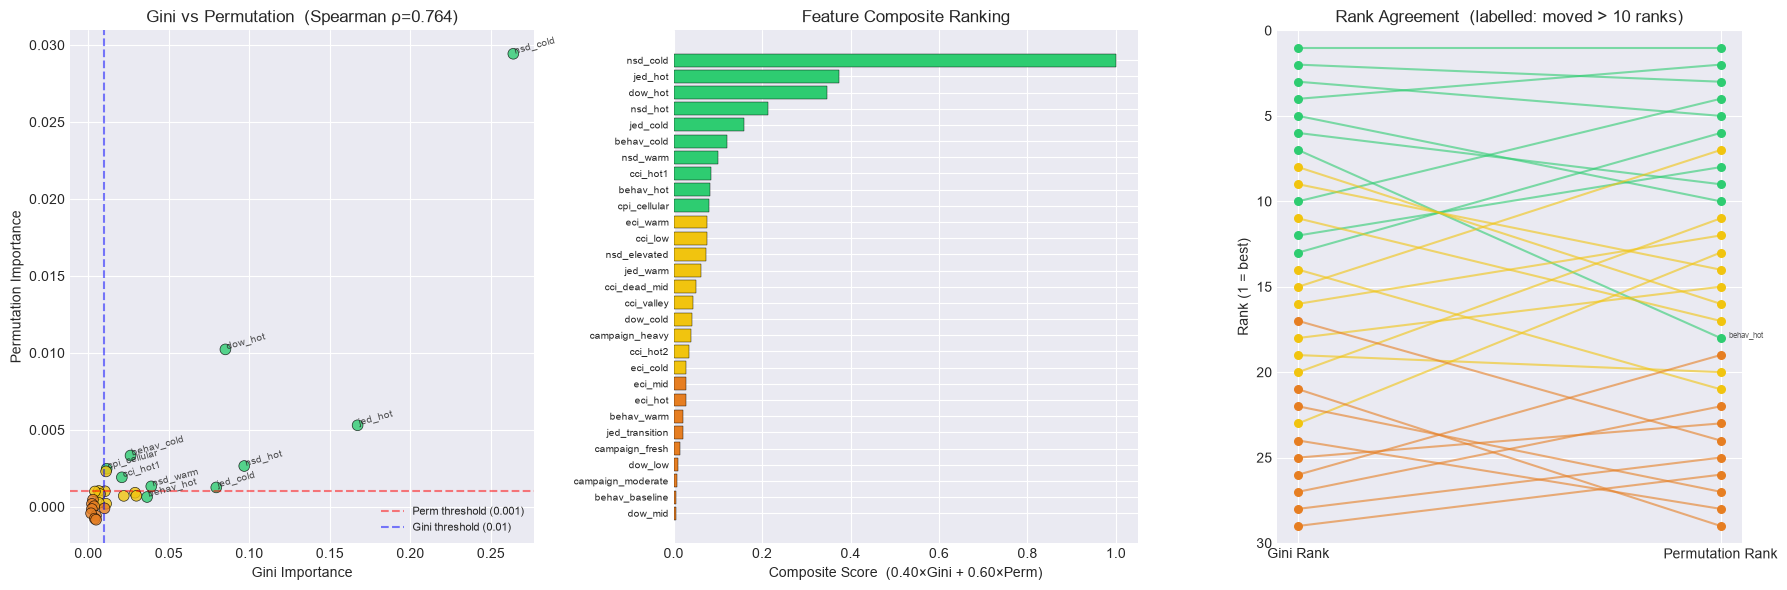

In [25]:
# ============================================================
# CELL 15D: RF FEATURE DIAGNOSTICS (BINARY FEATURE SPACE)
# ============================================================
from feature_research.model_training.rf import rf_diagnostics

rf_diag = rf_diagnostics(
    rf_result,
    df_rf_binary,
    RF_FEATURES_BINARY,
    TARGET_COL,
)

# ── Promote binary features into df_engineered for downstream cells ───────────
for feat in RF_FEATURES_BINARY:
    df_engineered[feat] = df_rf_binary[feat]

RF_FEATURES = RF_FEATURES_BINARY   # reassign for EBM / Venn trace cells

## Cell 16A — Stage 3 EBM Training

Trains and evaluates the Stage 3 Explainable Boosting Machine using the finalized Stage 3 feature set, with up to 5 pairwise interactions to preserve interpretability.

### Leakage safety

- Uses training rows only.
- The feature pipeline is refit inside every tuning and evaluation fold.
- A contract check verifies the factory output exactly matches `df_engineered[EBM_FEATURES]`.
- No imputation: invalid features fail loudly.
- Balanced sample weights are recomputed per fit.

### Tuning and evaluation

- Optuna tuning on `CV`
- Best trial must reproduce its fold scores on refit
- Separate 10-fold OOF evaluation
- `ebm_oof` provides one probability per training row for downstream threshold selection
- Fixed seeds keep runs deterministic

### Objective

Hyperparameters maximize:

**½ ROC-AUC + ½ high-recall partial AUC**

The partial AUC focuses on the ROC region with `TPR ≥ 0.70`, encouraging stronger ranking in the recall-sensitive operating range.

This objective affects tuning only. The EBM still fits log-loss, and its operating threshold is selected later from `ebm_oof`.

### Baseline

OOF AUC verdict:

- Δ ≥ −0.005 → **HOLD**
- Δ ≥ −0.010 → **BELOW TARGET**
- otherwise → **REGRESSED**

`EBM_BASELINE_AUC` is set from the first run under this protocol.

### Reruns

Set `EBM_PARAMS = ebm_result.params` to reuse the tuned hyperparameters while still rerunning OOF evaluation and the final fit.

In [27]:
# ============================================================
# CELL 16A: STAGE 3 EBM — TRAINING (OUT-OF-FOLD)
# ============================================================
from feature_research.model_training.ebm import train_ebm

EBM_FACTORY      = make_feature_pipeline   # EBM_FEATURES come from the base pipeline (confirmed)
EBM_BASELINE_AUC = 0.7949                    # first protocol run: set to this run's OOF AUC
EBM_PARAMS       = None                   # dict → skip tuning (e.g. ebm_result.params for reruns)

ebm_result = train_ebm(
    X_train, y_train, EBM_FEATURES,
    cv=CV,
    feature_factory=EBM_FACTORY,
    objective="auc_recall",   # ½ AUC + ½ pAUC(TPR≥0.70)
    n_trials=150,
    n_folds_eval=10,
    random_state=RANDOM_SEED,
    params=EBM_PARAMS,
    baseline_auc=EBM_BASELINE_AUC,
)

# Contract: ebm_pipe's input is exactly df_engineered[EBM_FEATURES]
pd.testing.assert_frame_equal(
    EBM_FACTORY().fit_transform(X_train, y_train)[EBM_FEATURES],
    df_engineered[EBM_FEATURES],
)

# Aliases consumed by downstream cells
ebm_pipe    = ebm_result.pipe        # ExplainableBoostingClassifier, fit on all training rows
ebm_params  = ebm_result.params      # best Optuna hyperparameters
ebm_metrics = ebm_result.metrics     # out-of-fold mean/std + recall@10%FPR + high-recall pAUC
ebm_study   = ebm_result.study       # raw Study (None if EBM_PARAMS was set)
ebm_oof     = ebm_result.oof_proba   # out-of-fold P(y=1); use for threshold selection

  0%|          | 0/150 [00:00<?, ?it/s]


Stage 3 · EBM
──────────────────────────────────────────────────────────────────────────────
Data       32,950 rows · 14 features · 3,712 positive (11.3%)
Features   refit per fold — FeaturePipeline
Tuning     150 trials (107 complete, 43 pruned) · 14166.7s
           best 5-fold ½AUC+½pAUC(TPR≥0.70) 0.7339 (reproduced ✓) · folds 0.724 0.736 0.736 0.738 0.735
Params     learning_rate 0.005384 · max_rounds 1300 · max_bins 416 · max_interaction_bins 128 · interactions 4 · balanced weights
OOF        10-fold AUC 0.7949 ± 0.0161 (moderate variance) · Recall@10%FPR 0.5779
           at 0.5: recall 0.6347 · precision 0.3588 · F1 0.4581 · F2 0.5497
Baseline   0.7949 · Δ +0.0000 → ✅ HOLD
Recall     high-recall pAUC (TPR≥0.70) 0.6768 ± 0.0218
Pairs      best with 0.7339 (105 trials) · without 0.7304 (2) · Δ +0.0035
           baseline compares OOF AUC; tuning maximised ½AUC+½pAUC(TPR≥0.70)


## Cell 16B — Stage 3 EBM Diagnostics

Ranks features from the final EBM fit on all training rows. This diagnostic informed the GLASS Stage 3 feature set.

### Evidence

- **Importance:** mean absolute contribution per term
- **Shape linearity:** R² against feature-bin midpoints
- **Effect size:** logit range of each shape
- **Redundancy:** linear features already represented by LR or RF
- **Correlation:** for |r| > 0.7, the lower-importance feature is the drop candidate
- **Composite score:** importance, effect size, non-linearity, point-biserial correlation, KS, and interaction participation

Composite scores are converted into relative feature tiers.

### Scope

Diagnostics are computed from the full-training fit and are descriptive only. Predictive performance is evaluated separately using the out-of-fold results from Cell 16A.

> **RF cross-check:** Use the RF source features, not the binary bin columns. The diagnostic warns if no RF/EBM feature overlap is found.


Stage 3 · EBM diagnostics (in-sample, all training rows)
──────────────────────────────────────────────────────────────────────────────
Terms      14 main effects · 4 interactions (7.8% of importance) · 32,950 rows
Importance 80% in top 10 · 90% top 14 · 95% top 16 · tail: campaign, economic_curvature_intensity & dow_month_encoded, decay_x_density & emp_var_rate_sigmoid_slope
Shape R²   linear (>0.9): dow_month_encoded, behavioral_favorability, emp_var_rate_sigmoid_slope, overlap_behavioral_score
           complex (<0.4): decay_x_density, euribor3m_sigmoid_slope, cons.conf.idx, age, default, economic_curvature_intensity
           not assessed: cpi_high_cellular (≤2 bins), overlap_default_clean (≤2 bins)
Effect     negligible (<0.01): none
           weak (<0.03): none
Pairs      decay_x_density & economic_curvature_intensity (0.0579), campaign & emp_var_rate_sigmoid_slope (0.0529), economic_curvature_intensity & dow_month_encoded (0.0448), decay_x_density & emp_var_rate_sigmoid_slop

,feature,tier,composite_score,imp_rank,linearity_r2,score_range,class_sep_r,class_sep_ks,verdict
composite_rank,,,,,,,,,
1,decay_x_density,🟢 TIER 1 (keep),0.6819,1,0.3270,2.6501,0.0000,0.0000,✅ NON-LINEAR — EBM adds unique value
2,cons.conf.idx,🟢 TIER 1 (keep),0.5630,7,0.2269,1.0698,0.0553,0.1965,✅ NON-LINEAR — EBM adds unique value
3,campaign,🟢 TIER 1 (keep),0.5101,16,0.8435,2.7213,0.0655,0.0787,✅ NON-LINEAR — EBM adds unique value
4,economic_curvature_intensity,🟢 TIER 1 (keep),0.4429,13,0.1096,2.4681,0.0000,0.0000,✅ NON-LINEAR — EBM adds unique value
5,age,🟢 TIER 1 (keep),0.3731,9,0.1562,0.5256,0.0287,0.0850,✅ NON-LINEAR — EBM adds unique value
6,dow_month_encoded,🟢 TIER 1 (keep),0.3172,2,0.9460,1.4654,0.0000,0.0000,"⚠️ linear + upstream, but in an interaction — ..."
7,campaign & emp_var_rate_sigmoid_slope,🟢 TIER 1 (keep),0.3130,15,NaN,2.5618,0.0000,0.0000,🔗 INTERACTION TERM
8,euribor3m_sigmoid_slope,🟢 TIER 1 (keep),0.2924,6,0.2638,1.1560,0.0000,0.0000,✅ NON-LINEAR — EBM adds unique value
9,decay_x_density & economic_curvature_intensity,🟢 TIER 1 (keep),0.2884,12,NaN,2.2169,0.0000,0.0000,🔗 INTERACTION TERM



Tier 3 (test removal): none
Tier 4 (safe to cut):  none


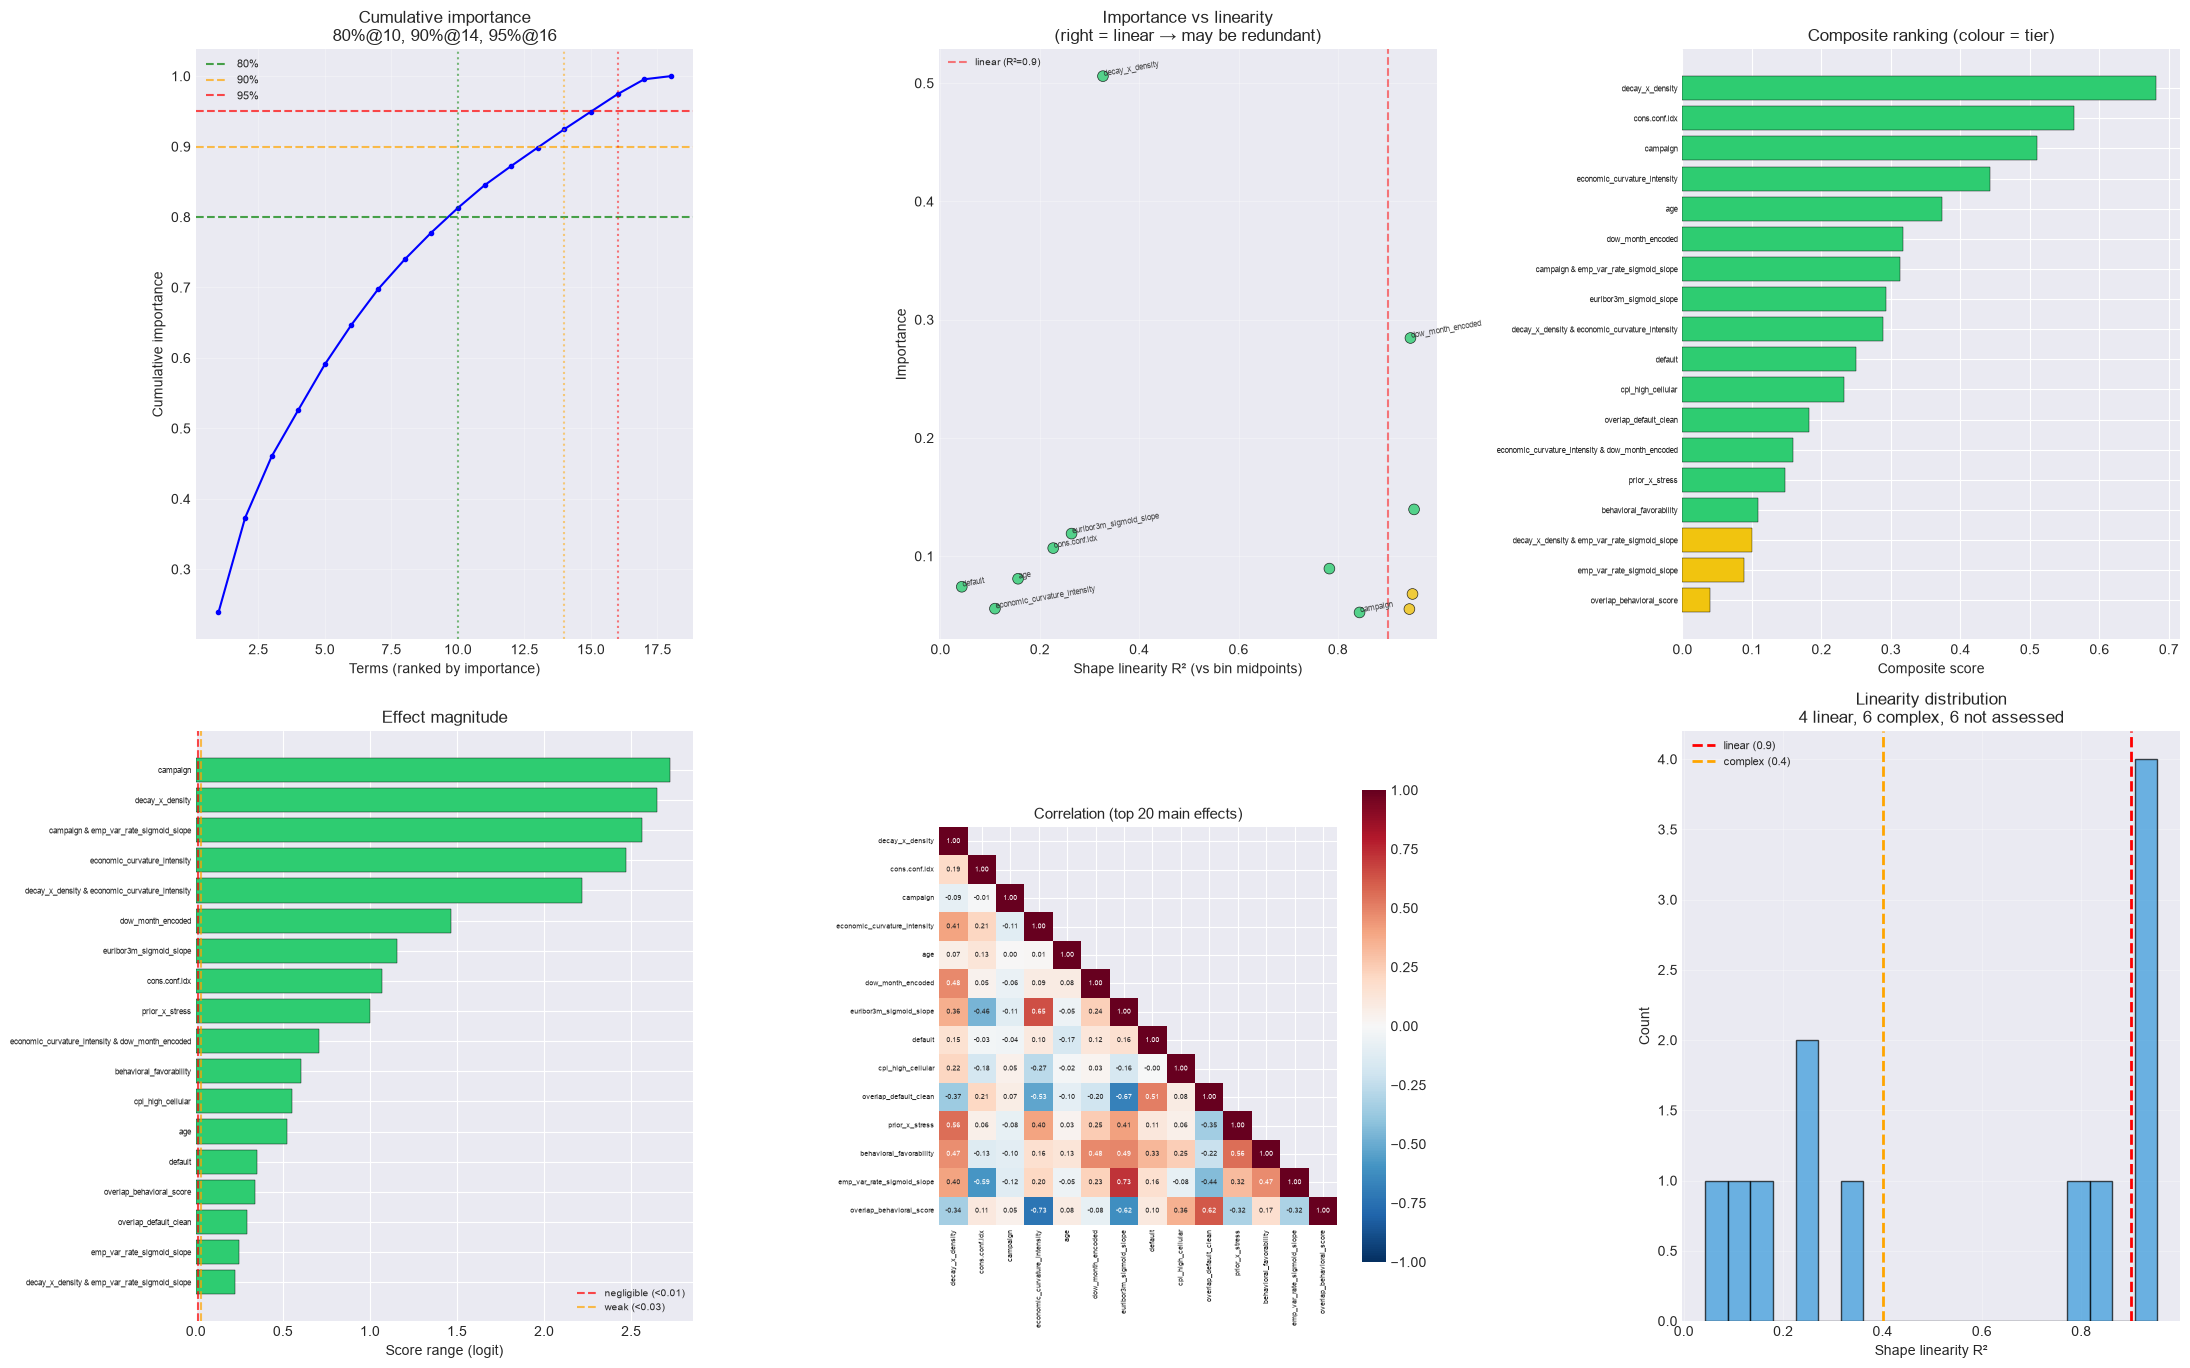

In [28]:
# ============================================================
# CELL 16B: STAGE 3 EBM — DIAGNOSTICS (IN-SAMPLE, NO REFIT)
# ============================================================
from feature_research.model_training.ebm import ebm_diagnostics

ebm_diag = ebm_diagnostics(
    result=ebm_result,
    X=df_engineered[EBM_FEATURES],   # = full-fit model input (contract-checked in 16A)
    sep_df=df_separation,
    lr_features=LR_FEATURES,
    rf_features=RF_FEATURES,         # RF source features — not RF_FEATURES_BINARY
)

ebm_importance_df = ebm_diag["importance_df"]
ebm_linearity_df  = ebm_diag["linearity_df"]
ebm_composite_df  = ebm_diag["composite_df"]
ebm_batch1        = ebm_diag["batch1"]
ebm_safe_cut_list = ebm_diag["safe_cut_list"]

## Cell 17A — GLASS Arbiter

Combines the three stage scores with the GLASS Arbiter: a weighted-confidence vote over LR, RF and EBM that may abstain when the vote is weak. Same rules as the cascade's Stage 4 arbiter, applied to the research stages.

#### Inputs

- `lr_oof`, `rf_oof`, `ebm_oof`: one out-of-fold score per training row, from Cells 14–16.
- No models are retrained, and there is no second split.

#### Rules (mirrors cascade)

- **Thresholds:** highest score at which each stage still reaches 70% recall.
- **Weights:** ½ inverse Brier + ½ accuracy at that threshold.
- **Vote:** each stage votes at its threshold; confidence = distance from the threshold × weight. Larger total confidence wins.
- **Abstention:** abstain when the winning side's confidence < `min_weighted_confidence`, chosen by F2 on retained rows with coverage ≥ 50% (fallback 0.07).

#### Evaluation

There is no test set here, so the configuration is cross-fitted on `CV`: fit on four folds, frozen, applied to the fifth. Every metric is out-of-fold. The all-rows fit (`arbiter_config`) is the configuration the cascade would freeze.


In [29]:
# ============================================================
# CELL 17A: GLASS ARBITER — CROSS-FITTED ON STAGE OOF SCORES
# ============================================================
from feature_research.model_training.glass_arbiter import cross_fit_arbiter

ARBITER_TARGET_RECALL = 0.70

# Contract: arbiter inputs are the stage OOF scores, aligned to the training rows
P_oof = pd.DataFrame({"lr": lr_oof, "rf": rf_oof, "ebm": ebm_oof})
assert P_oof.index.equals(y_train.index), "stage OOF scores are not aligned with y_train"
assert P_oof.notna().all().all(), "missing stage OOF scores"

arbiter_result = cross_fit_arbiter(
    P_oof, y_train,
    cv=CV,
    rule="recall",
    target_recall=ARBITER_TARGET_RECALL,
)

# Aliases consumed by downstream cells
arbiter_config  = arbiter_result.config        # all-rows fit: thresholds, weights, min_weighted_confidence
arbiter_metrics = arbiter_result.metrics       # out-of-fold, one row per stage / arbiter variant
arbiter_proba   = arbiter_result.proba         # cross-fitted weighted score
arbiter_pred    = arbiter_result.pred          # cross-fitted decision (-1 abstain / 0 / 1)
stage_oof_pred  = arbiter_result.model_preds   # cross-fitted per-stage decisions at their thresholds


GLASS Arbiter · recall (target recall 0.70) thresholds
──────────────────────────────────────────────────────────────────────────────
Inputs     32,950 rows · 3,712 positive (11.3%) · stage OOF scores lr, rf, ebm · 5-fold cross-fit
           values: all-rows fit [range across cross-fit folds]
Thresholds LR 0.4341 [0.4316–0.4372] · RF 0.3945 [0.3879–0.4047] · EBM 0.3986 [0.3956–0.4013]
Weights    LR 0.321 [0.321–0.322] · RF 0.336 [0.335–0.337] · EBM 0.343 [0.341–0.343]
Abstain    min_weighted_confidence 0.11 (F2 sweep on fit rows, coverage ≥ 50%; fit F2 0.6731, coverage 53.9%) · folds 0.11, 0.11, 0.11, 0.11, 0.11
Calibrated LR Brier 0.1800 ECE 0.3063 · RF Brier 0.1660 ECE 0.2792 · EBM Brier 0.1628 ECE 0.2735
Disagree   LR≠RF 3.6% (right: LR 41% / RF 59%) · LR≠EBM 9.2% (right: LR 39% / EBM 61%) · RF≠EBM 8.3% (right: RF 42% / EBM 58%)


,coverage,accuracy,precision,recall,f1,f2,roc_auc,recall_at_10fpr
LR,1.0000,0.7366,0.2553,0.6977,0.3738,0.5181,0.7749,0.5073
RF,1.0000,0.7431,0.2612,0.7004,0.3805,0.5242,0.7872,0.5711
EBM,1.0000,0.7560,0.2730,0.7007,0.3929,0.5335,0.7945,0.5779
Arbiter (no abstain),1.0000,0.7510,0.2687,0.7029,0.3887,0.5312,0.7922,0.5692
Arbiter (abstain),0.5386,0.7575,0.3700,0.8473,0.5151,0.6735,0.8404,NaN


## Cell 17B — Threshold-Rule Comparison

Optional. Re-runs the cross-fitted arbiter with Youden and F2 thresholds in place of the 70%-recall threshold and stacks the out-of-fold metrics. Off by default; set `RUN_THRESHOLD_EXPERIMENTS = True` to run it.

In [30]:
# ============================================================
# CELL 17B: GLASS ARBITER — THRESHOLD-RULE COMPARISON (OPTIONAL)
# ============================================================
from feature_research.model_training.glass_arbiter import compare_variants, cross_fit_arbiter
from feature_research.model_training.shared.report import show_table

RUN_THRESHOLD_EXPERIMENTS = True   # True → add Youden and F2 threshold rules (same cross-fit)

arbiter_variants = {"recall": arbiter_result}
if RUN_THRESHOLD_EXPERIMENTS:
    for _rule in ("youden", "f2"):
        arbiter_variants[_rule] = cross_fit_arbiter(P_oof, y_train, cv=CV, rule=_rule, verbose=False)

arbiter_comparison = compare_variants(arbiter_variants)
if len(arbiter_variants) > 1:
    show_table(arbiter_comparison.round(4))
else:
    print("Threshold-rule comparison skipped (RUN_THRESHOLD_EXPERIMENTS = False)")

coverage  accuracy  precision  recall  \
thresholds model                                                         
recall     LR                      1.0000    0.7366     0.2553  0.6977   
           RF                      1.0000    0.7431     0.2612  0.7004   
           EBM                     1.0000    0.7560     0.2730  0.7007   
           Arbiter (no abstain)    1.0000    0.7510     0.2687  0.7029   
           Arbiter (abstain)       0.5386    0.7575     0.3700  0.8473   
youden     LR                      1.0000    0.8005     0.3132  0.6463   
           RF                      1.0000    0.8188     0.3381  0.6352   
           EBM                     1.0000    0.8432     0.3792  0.6156   
           Arbiter (no abstain)    1.0000    0.8223     0.3445  0.6393   
           Arbiter (abstain)       0.5550    0.8214     0.4290  0.8089   
f2         LR                      1.0000    0.8005     0.3133  0.6471   
           RF                      1.0000    0.8188     0.3381  0.6352   
           EBM                     1.0000    0.8431     0.3790  0.6156   
           Arbiter (no abstain)    1.0000    0.8222     0.3443  0.6395   
           Arbiter (abstain)       0.5527    0.8210     0.4290  0.8109   

                                     f1      f2  roc_auc  recall_at_10fpr  
thresholds model                                                           
recall     LR                    0.3738  0.5181   0.7749           0.5073  
           RF                    0.3805  0.5242   0.7872           0.5711  
           EBM                   0.3929  0.5335   0.7945           0.5779  
           Arbiter (no abstain)  0.3887  0.5312   0.7922           0.5692  
           Arbiter (abstain)     0.5151  0.6735   0.8404              NaN  
youden     LR                    0.4219  0.5329   0.7749           0.5073  
           RF                    0.4413  0.5403   0.7872           0.5711  
           EBM                   0.4693  0.5473   0.7945           0.5779  
           Arbiter (no abstain)  0.4477  0.5459   0.7922           0.5692  
           Arbiter (abstain)     0.5606  0.6872   0.8423              NaN  
f2         LR                    0.4222  0.5334   0.7749           0.5073  
           RF                    0.4413  0.5403   0.7872           0.5711  
           EBM                   0.4692  0.5473   0.7945           0.5779  
           Arbiter (no abstain)  0.4476  0.5459   0.7922           0.5692  
           Arbiter (abstain)     0.5611  0.6883   0.8425              NaN

## Cell 17C — Sample Trace

Shows where the three stages agree and which targets none of them catch. Uses the cross-fitted decisions from 17A, so every row is out-of-fold.

#### Agreement trace

- Agreement rates, pairwise disagreement, targets caught by one stage only.
- Correctness patterns and score states (Silent / Candidate / Confirmed relative to each stage's threshold).
- Venn diagram of correct decisions and caught targets.

#### Missed positives

- Hard floor: targets no stage catches, and how many were near misses (≥ 85% of a threshold).
- Feature profile: hard-floor targets vs targets all three catch (Mann-Whitney p, Cohen's d).

Saves the Venn diagram to `research_logs/figures/venn_diagram_trace.png` and the workbook to `research_logs/missed_sample_analysis.xlsx`. Set `SAVE_TRACE = False` for inline output only.

Replaces the former Cells 18 (bitmask trace) and 19 (missed-sample analysis).



GLASS Arbiter · agreement trace (cross-fitted, all training rows)
──────────────────────────────────────────────────────────────────────────────
Agreement  all 3 agree 89.5% (all correct 69.2% · all wrong 20.3%) · any disagreement 10.5% · target 65–75%
Pairwise   LR VS RF 3.6% · LR VS EBM 9.2% · RF VS EBM 8.3% (decisions differ)
Catches    LR 69.8% · RF 70.0% · EBM 70.1% of 3,712 positives · all 3 66.6% · none (hard floor) 26.4%
Unique     LR 33 targets (0.9%) · RF 27 targets (0.7%) · EBM 88 targets (2.4%) caught by one stage only
Alone      LR only correct 203 (target rate 16.3%) · RF only correct 168 (target rate 16.1%) · EBM only correct 1,302 (target rate 6.8%)
Verdict    ⚠️ HIGH AGREEMENT — diversity tuning needed

Correctness patterns


count   share  target_rate
LR RF EBM                            
✓  ✓  ✓    22797  0.6919       0.1085
✗  ✗  ✗     6678  0.2027       0.1466
      ✓     1302  0.0395       0.0676
✓  ✓  ✗      990  0.0300       0.0727
✗  ✓  ✓      530  0.0161       0.0528
✓  ✗  ✓      282  0.0086       0.0426
      ✗      203  0.0062       0.1626
✗  ✓  ✗      168  0.0051       0.1607


Score states (margin 0.07) — top 15


count   share  target_rate
LR state     RF state     EBM state                               
00 Silent    00 Silent    00 Silent     14247  0.4324       0.0390
11 Confirmed 11 Confirmed 11 Confirmed   8172  0.2480       0.3026
00 Silent    10 Candidate 10 Candidate   2913  0.0884       0.0635
                          00 Silent      1425  0.0432       0.0470
             00 Silent    10 Candidate   1364  0.0414       0.0623
11 Confirmed 11 Confirmed 10 Candidate   1025  0.0311       0.0556
00 Silent    10 Candidate 11 Confirmed    805  0.0244       0.0870
10 Candidate 00 Silent    00 Silent       547  0.0166       0.0713
                          10 Candidate    405  0.0123       0.0667
             10 Candidate 10 Candidate    295  0.0090       0.0576
11 Confirmed 11 Confirmed 00 Silent       261  0.0079       0.0575
             10 Candidate 10 Candidate    223  0.0068       0.0717
                          00 Silent       195  0.0059       0.0462
10 Candidate 11 Confirmed 11 Confirmed    146  0.0044       0.1507
                          10 Candidate    142  0.0043       0.1268

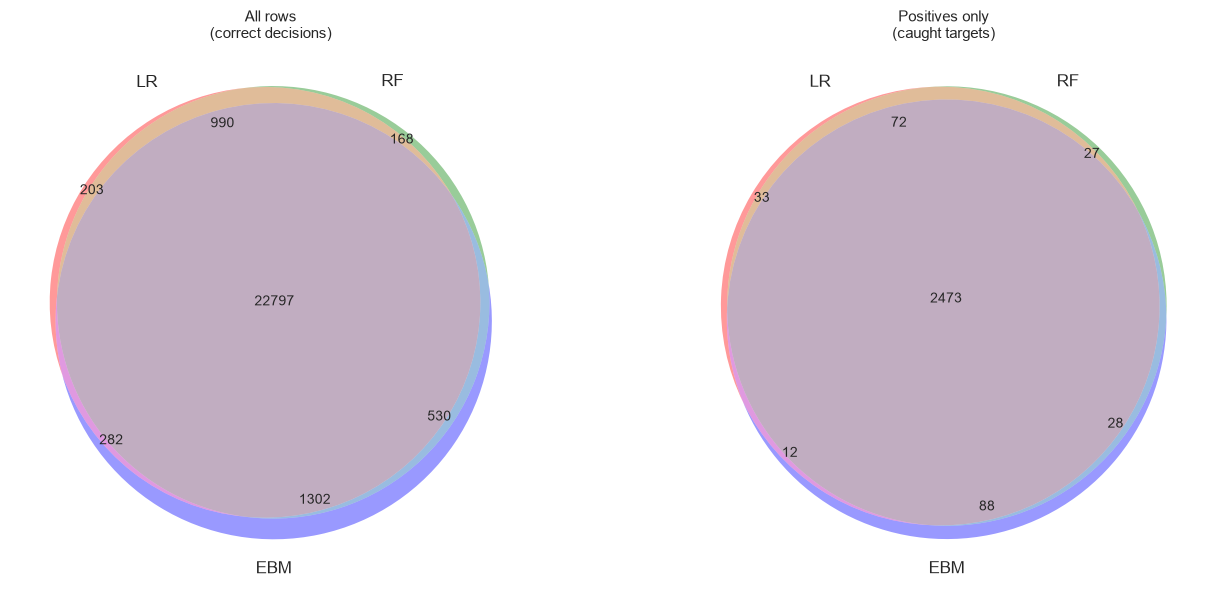

Saved      C:\Users\phill\projects\ai-business-coach-clean\prototype\bank_pipeline\feature_research\research_logs\figures\venn_diagram_trace.png

GLASS Arbiter · missed positives (cross-fitted)
──────────────────────────────────────────────────────────────────────────────
Positives  3,712 · hard floor 979 (26.4%) · all 3 catch 2,473 (66.6%)
           single-stage misses: LR 28 · RF 12 · EBM 72
Floor      near-miss (any stage ≥ 85% of its threshold) 384 · invisible 595
Profile    45 features · caught (all 3) vs hard floor · top 15 by Mann-Whitney p


,caught_mean,floor_mean,delta_mean,cohens_d,mannwhitney_p,in_LR,in_RF,in_EBM
feature,,,,,,,,
cellular_crisis,0.9163,0.0051,-0.9112,-4.5061,0.0,True,False,False
euribor3m_local_rate,0.3409,0.0584,-0.2825,-2.6390,0.0,True,False,False
nsd_cold,0.0137,0.9867,0.9730,8.4269,0.0,False,True,False
jed_cold,0.0137,0.8417,0.8279,3.0558,0.0,False,True,False
cci_dead_mid,0.0004,0.5802,0.5798,1.6600,0.0,False,True,False
decay_x_density,0.0635,0.0001,-0.0634,-1.7174,0.0,False,False,True
euribor3m_sigmoid_slope,0.7465,0.0196,-0.7269,-4.6090,0.0,False,False,True
economic_curvature_intensity,0.0983,0.0386,-0.0597,-2.2657,0.0,False,False,True
overlap_default_clean,0.0142,0.7395,0.7254,2.2570,0.0,False,False,True


Saved      C:\Users\phill\projects\ai-business-coach-clean\prototype\bank_pipeline\feature_research\research_logs\missed_sample_analysis.xlsx


In [31]:
# ============================================================
# CELL 17C: GLASS ARBITER — SAMPLE TRACE (AGREEMENT + MISSED POSITIVES)
# ============================================================
from feature_research.config import FIG_DIR, OUTPUT_DIR
from feature_research.model_training.glass_arbiter import run_bitmask_trace, run_missed_analysis

SAVE_TRACE   = True               # False → inline output only, no files
RESEARCH_DIR = Path(OUTPUT_DIR)   # feature_research/research_logs (package-anchored)
FIGURES_DIR  = Path(FIG_DIR)      # feature_research/research_logs/figures

# Profiling frame: engineered columns + RF binary columns, training rows only
assert df_rf_binary.index.equals(df_engineered.index), "RF binary frame not aligned with df_engineered"
trace_features = df_engineered.join(
    df_rf_binary[[c for c in RF_FEATURES_BINARY if c not in df_engineered.columns]]
)

arbiter_trace = run_bitmask_trace(
    stage_oof_pred, P_oof, arbiter_result.row_thresholds, y_train,
    save_dir=FIGURES_DIR if SAVE_TRACE else None,   # → venn_diagram_trace.png
)

missed_groups, missed_profile, missed_near = run_missed_analysis(
    trace_features, y_train, stage_oof_pred, P_oof, arbiter_result.row_thresholds,
    LR_FEATURES, RF_FEATURES_BINARY, EBM_FEATURES,
    excel_path=RESEARCH_DIR / "missed_sample_analysis.xlsx" if SAVE_TRACE else None,
)

In [32]:
# ============================================================
# CELL 18: RUN VALIDATION — contracts, OOF hand-offs, arbiter, run manifest
# ============================================================
import hashlib, json, platform, subprocess

import interpret, optuna, sklearn
from feature_research.config import FIG_DIR, OUTPUT_DIR
from feature_research.model_training.glass_arbiter import MODELS, fit_arbiter
from feature_research.model_training.shared.report import fmt_list, show_table, title


def _fp(obj) -> str:
    """Fingerprint of a frame / series / index: names + dtypes + index + values."""
    df = obj.to_frame(index=False) if isinstance(obj, pd.Index) else obj
    df = df.to_frame() if isinstance(df, pd.Series) else df
    h = hashlib.sha256(json.dumps([(str(c), str(t)) for c, t in df.dtypes.items()]).encode())
    h.update(pd.util.hash_pandas_object(df, index=True).values.tobytes())
    return h.hexdigest()[:16]


def _flatten(d: dict, prefix: str = "") -> dict:
    out = {}
    for k, v in d.items():
        key = f"{prefix}{k}"
        out.update(_flatten(v, f"{key}.") if isinstance(v, dict) else {key: v})
    return out


def _git(*args) -> str:
    r = subprocess.run(["git", *args], capture_output=True, text=True, cwd=BANK_ROOT)
    return r.stdout.strip() if r.returncode == 0 else "unavailable"


def _rel(p: Path) -> str:
    try:
        return str(p.resolve().relative_to(Path(BANK_ROOT).resolve()))
    except ValueError:
        return str(p)


# Stage registry: everything below loops over this (same aliases in every stage cell)
STAGES = {
    "lr":  dict(pipe=lr_pipe,  features=LR_FEATURES,        oof=lr_oof,  metrics=lr_metrics,  params=lr_params),
    "rf":  dict(pipe=rf_pipe,  features=RF_FEATURES_BINARY, oof=rf_oof,  metrics=rf_metrics,  params=rf_params),
    "ebm": dict(pipe=ebm_pipe, features=EBM_FEATURES,       oof=ebm_oof, metrics=ebm_metrics, params=ebm_params),
}

# 1. Split: y_train is still the Cell 5 Series (nothing rebound it)
assert isinstance(y_train, pd.Series), "y_train was rebound — must stay the Cell 5 Series"
assert y_train.index.equals(X_train.index), "y_train no longer aligned with X_train"

# 2. Feature-block contracts: fresh pipelines reproduce every trained block
fresh = make_feature_pipeline().fit_transform(X_train, y_train)
_shared = [c for c in df_engineered.columns if c in fresh.columns]   # df_engineered keeps a subset
assert set(LR_FEATURES) | set(EBM_FEATURES) <= set(_shared), "model features missing from df_engineered"
pd.testing.assert_frame_equal(fresh[_shared], df_engineered[_shared])
pd.testing.assert_frame_equal(
    make_rf_feature_pipeline().fit_transform(X_train, y_train)[RF_FEATURES_BINARY],
    df_rf_binary[RF_FEATURES_BINARY],
)
ebm_block = fresh if EBM_FACTORY is make_feature_pipeline else EBM_FACTORY().fit_transform(X_train, y_train)
pd.testing.assert_frame_equal(ebm_block[EBM_FEATURES], df_engineered[EBM_FEATURES])

# 3. Model inputs + OOF hand-offs, per stage
for name, s in STAGES.items():
    assert list(s["pipe"].feature_names_in_) == list(s["features"]), f"{name}_pipe feature mismatch"
    oof = s["oof"]
    assert isinstance(oof, pd.Series) and oof.index.equals(y_train.index), f"{name}_oof not aligned with y_train"
    assert np.isfinite(oof.to_numpy()).all() and oof.between(0, 1).all(), f"{name}_oof not finite probabilities"

# 4. Arbiter: built from the current stage OOF scores; config reproduces; outputs aligned
pd.testing.assert_frame_equal(P_oof, pd.DataFrame({m: STAGES[m]["oof"] for m in MODELS}))
_refit = fit_arbiter(P_oof, y_train, rule="recall", target_recall=ARBITER_TARGET_RECALL)
assert (_refit.thresholds, _refit.weights, _refit.min_conf) == (
    arbiter_config.thresholds, arbiter_config.weights, arbiter_config.min_conf
), "arbiter config does not reproduce"
for name, out in (("arbiter_proba", arbiter_proba), ("arbiter_pred", arbiter_pred)):
    assert out.index.equals(y_train.index), f"{name} not aligned with y_train"
assert set(np.unique(arbiter_pred)) <= {-1, 0, 1}, "arbiter_pred has values outside {-1, 0, 1}"

# 5. Run manifest (no timestamps or runtimes, so two identical runs give identical files)
_sha, _status = _git("rev-parse", "--short", "HEAD"), _git("status", "--porcelain")
manifest = {
    "git_sha": _sha + ("+dirty" if _status not in ("", "unavailable") else ""),
    "random_seed": RANDOM_SEED,
    "fe_params": FE_PARAMS,
    "train_rows": len(X_train),
    "train_index_fp": _fp(X_train.index),
    "blocks": {
        "df_engineered": _fp(df_engineered[_shared]),
        "lr_features": _fp(df_engineered[LR_FEATURES]),
        "rf_features_binary": _fp(df_rf_binary[RF_FEATURES_BINARY]),
        "ebm_features": _fp(df_engineered[EBM_FEATURES]),
    },
    "stages": {
        name: {
            "params": s["params"],
            "oof_auc": s["metrics"]["auc_mean"],
            "oof_fp": _fp(s["oof"]),
        }
        for name, s in STAGES.items()
    },
    "arbiter": {
        "thresholds": arbiter_config.thresholds,
        "weights": arbiter_config.weights,
        "min_weighted_confidence": arbiter_config.min_conf,
        "proba_fp": _fp(arbiter_proba),
        "pred_fp": _fp(arbiter_pred),
        "metrics": json.loads(arbiter_metrics.round(10).to_json(orient="index")),   # NaN → null
    },
    "versions": {"python": platform.python_version(), "pandas": pd.__version__,
                 "numpy": np.__version__, "sklearn": sklearn.__version__,
                 "optuna": optuna.__version__, "interpret": interpret.__version__},
}
manifest = json.loads(json.dumps(manifest, default=str))   # plain JSON types (numpy → python)

manifest_path = Path(OUTPUT_DIR) / "run_manifest.json"
previous = json.loads(manifest_path.read_text()) if manifest_path.exists() else None
manifest_path.write_text(json.dumps(manifest, indent=2))

# 6. Report
title("RUN VALIDATION")
print("Contracts  ✓ split · ✓ feature blocks reproduce · ✓ model inputs · ✓ OOF hand-offs · ✓ arbiter")
print(f"Commit     {manifest['git_sha']} · seed {RANDOM_SEED} · {len(X_train):,} training rows")
show_table(pd.DataFrame({
    name: {"features": len(s["features"]), "OOF AUC": round(s["metrics"]["auc_mean"], 4),
           "OOF fingerprint": manifest["stages"][name]["oof_fp"]}
    for name, s in STAGES.items()
}).T)
show_table(pd.DataFrame(manifest["blocks"], index=["fingerprint"]).T)

if previous is None:
    print("Determinism first manifest — rerun from a clean kernel to compare")
else:
    old, new = _flatten(previous), _flatten(manifest)
    changed = sorted(k for k in old.keys() | new.keys() if old.get(k) != new.get(k))
    print("Determinism ✓ identical to the previous run's manifest" if not changed
          else f"Determinism ✗ {len(changed)} field(s) differ from the previous run: {fmt_list(changed)}")

dirs = {Path(OUTPUT_DIR), Path(FIG_DIR)} | ({Path(RESEARCH_DIR)} if "RESEARCH_DIR" in globals() else set())
written = sorted({p for d in dirs if d.exists() for p in d.rglob("*") if p.is_file()})
print(f"Files      {len(written)} in output dirs")
for p in written:
    print(f"           {_rel(p)}")
print(f"Manifest   {_rel(manifest_path)}")


RUN VALIDATION
──────────────────────────────────────────────────────────────────────────────
Contracts  ✓ split · ✓ feature blocks reproduce · ✓ model inputs · ✓ OOF hand-offs · ✓ arbiter
Commit     f845448+dirty · seed 42 · 32,950 training rows


,features,OOF AUC,OOF fingerprint
lr,3,0.7762,71522e356e43e2c8
rf,29,0.7886,4bd4272cab5bb748
ebm,14,0.7949,d10e29424f1c6e68


,fingerprint
df_engineered,0d2d5cad0688ba47
lr_features,f99ef331ed8889f8
rf_features_binary,d471a199456c613d
ebm_features,0a8f77521626bae0


Determinism ✓ identical to the previous run's manifest
Files      23 in output dirs
           feature_research\research_logs\feature_rankings.csv
           feature_research\research_logs\figures\01_nr.employed.png
           feature_research\research_logs\figures\02_euribor3m.png
           feature_research\research_logs\figures\03_emp.var.rate.png
           feature_research\research_logs\figures\04_month.png
           feature_research\research_logs\figures\05_previous.png
           feature_research\research_logs\figures\06_cons.price.idx.png
           feature_research\research_logs\figures\07_contact.png
           feature_research\research_logs\figures\08_cons.conf.idx.png
           feature_research\research_logs\figures\09_default.png
           feature_research\research_logs\figures\10_campaign.png
           feature_research\research_logs\figures\11_education.png
           feature_research\research_logs\figures\12_marital.png
           feature_research\research_logs\figur